<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Abrikosov_Vortex_Visualization_with_CuPy_QuTiP_K3D_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!pip install -q "numpy>=2.0" "k3d==2.18.1" trimesh "cupy-cuda12x>=13.0,<14" "qutip==5.3.1" matplotlib ipywidgets

# Enable Colab widget support.
from google.colab import output
output.enable_custom_widget_manager()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.5/745.5 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.9 MB/s eta 0:00:00


Large-area superconducting-film configuration
  GPU:                    Tesla T4
  CuPy:                   13.6.0
  QuTiP:                  5.3.1
  K3D:                    2.18.1
  Free VRAM:              14.46 GiB
  Total VRAM:             14.56 GiB
  Film:                    1000.0 x 1000.0 um
  Film area:               1.000 mm^2
  Effective xi:            1.000 um
  Nominal core diameter:   2.000 um
  Applied field:           0.750 uT
  Expected flux quanta:    362.7
  Triangular spacing:      56.4 um
  Grid:                    640 x 640
  dx, dy:                  1.565, 1.565 xi
  Physical dx, dy:         1.565, 1.565 um

Initial vortex population requested: 363

Imprinting 363 initial vortices...
  Imprinted 100/363 vortices
  Imprinted 200/363 vortices
  Imprinted 300/363 vortices

Step   500/4000 | t/tau_GL =    15.00 | max|psi| = 1.0000 | elapsed = 1.6 s
Step  1000/4000 | t/tau_GL =    30.00 | max|psi| = 1.0000 | elapsed = 2.1 s
Step  1500/4000 | t/tau_GL =    45.00 | max|psi|

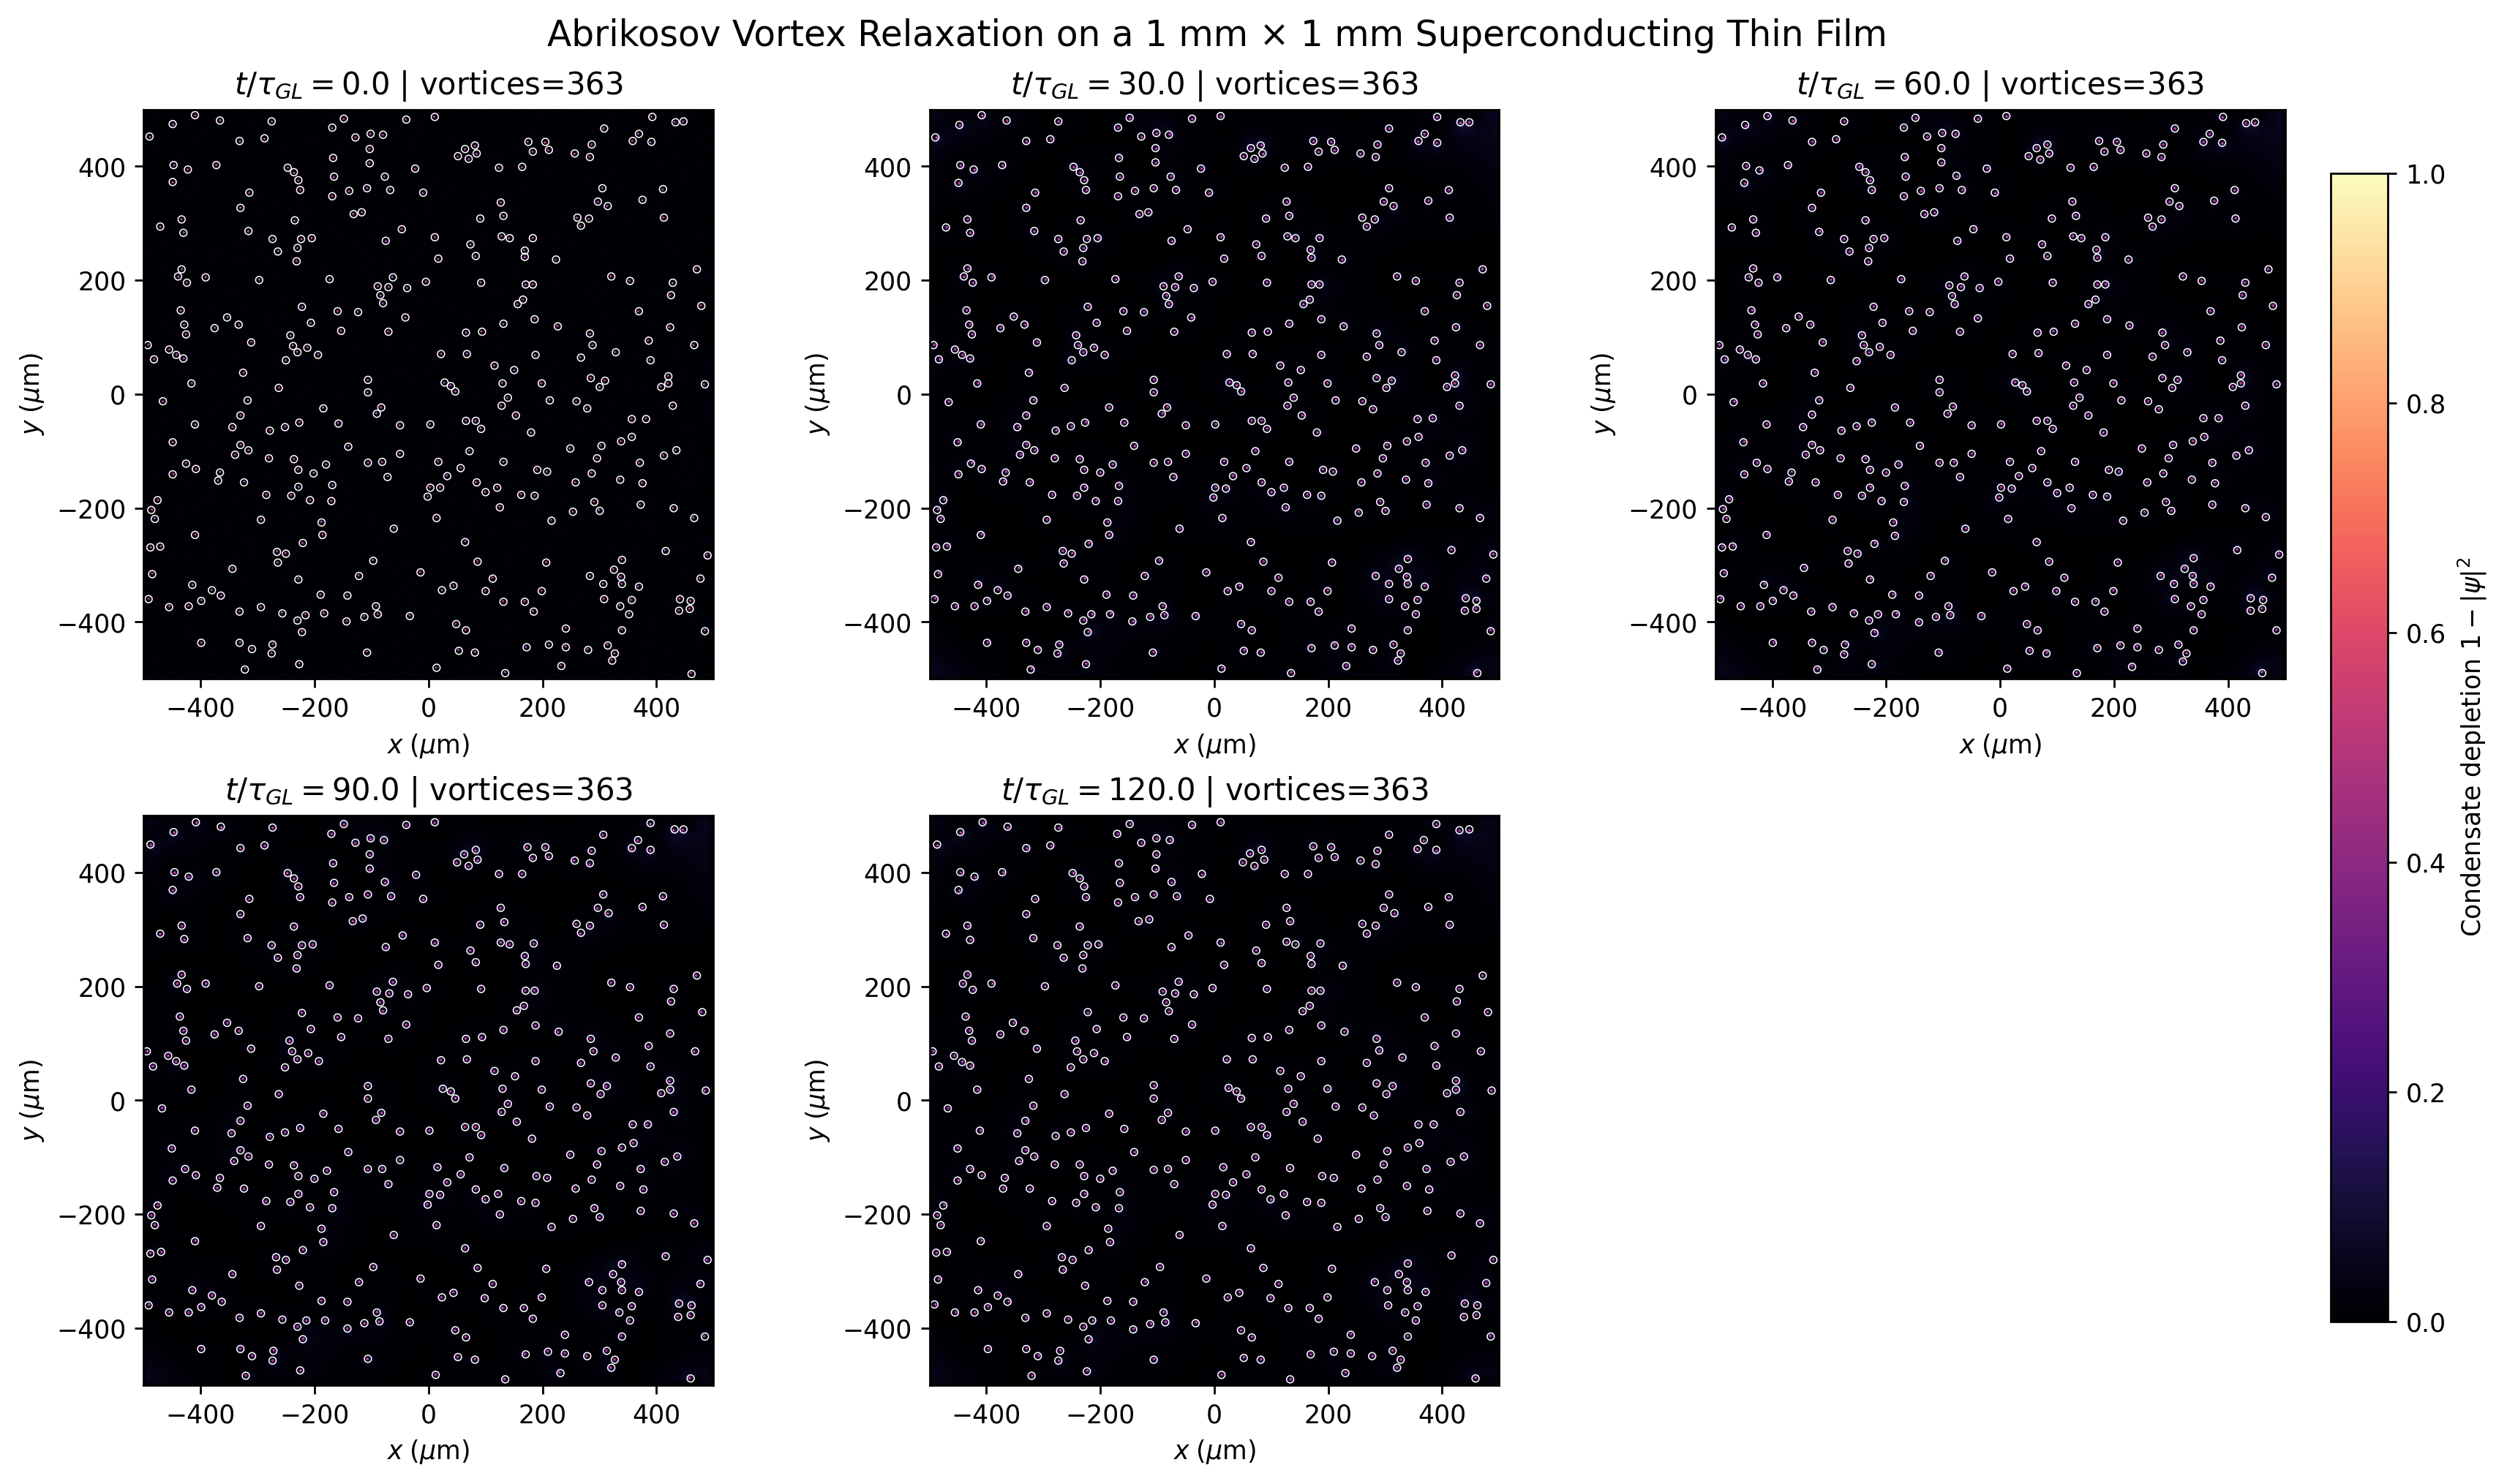

K3D multi-snapshot serialization

  Snapshot 1/5 | t/tau_GL=0.00 | vortices=363 | objects=4 | heatmap=321x321 | HTML=2.32 MiB
  Snapshot 2/5 | t/tau_GL=30.00 | vortices=363 | objects=4 | heatmap=321x321 | HTML=2.46 MiB
  Snapshot 3/5 | t/tau_GL=60.00 | vortices=363 | objects=4 | heatmap=321x321 | HTML=2.46 MiB
  Snapshot 4/5 | t/tau_GL=90.00 | vortices=363 | objects=4 | heatmap=321x321 | HTML=2.46 MiB
  Snapshot 5/5 | t/tau_GL=120.00 | vortices=363 | objects=4 | heatmap=321x321 | HTML=2.46 MiB

K3D rendering path
  Mode: five standalone HTML scenes
  Snapshot selector: enabled
  Widget object transport: bypassed
  Directory: /content/abrikosov_1mm_k3d_snapshots
  Port: 38143



<IPython.core.display.Javascript object>

QuTiP reduced phase probe
  Interval 1: activity=4.403677e-04, normalized=1.000, gamma_phi=0.04200
  Interval 2: activity=3.402507e-05, normalized=0.077, gamma_phi=0.00509
  Interval 3: activity=3.092027e-05, normalized=0.070, gamma_phi=0.00481
  Interval 4: activity=2.879982e-05, normalized=0.065, gamma_phi=0.00462



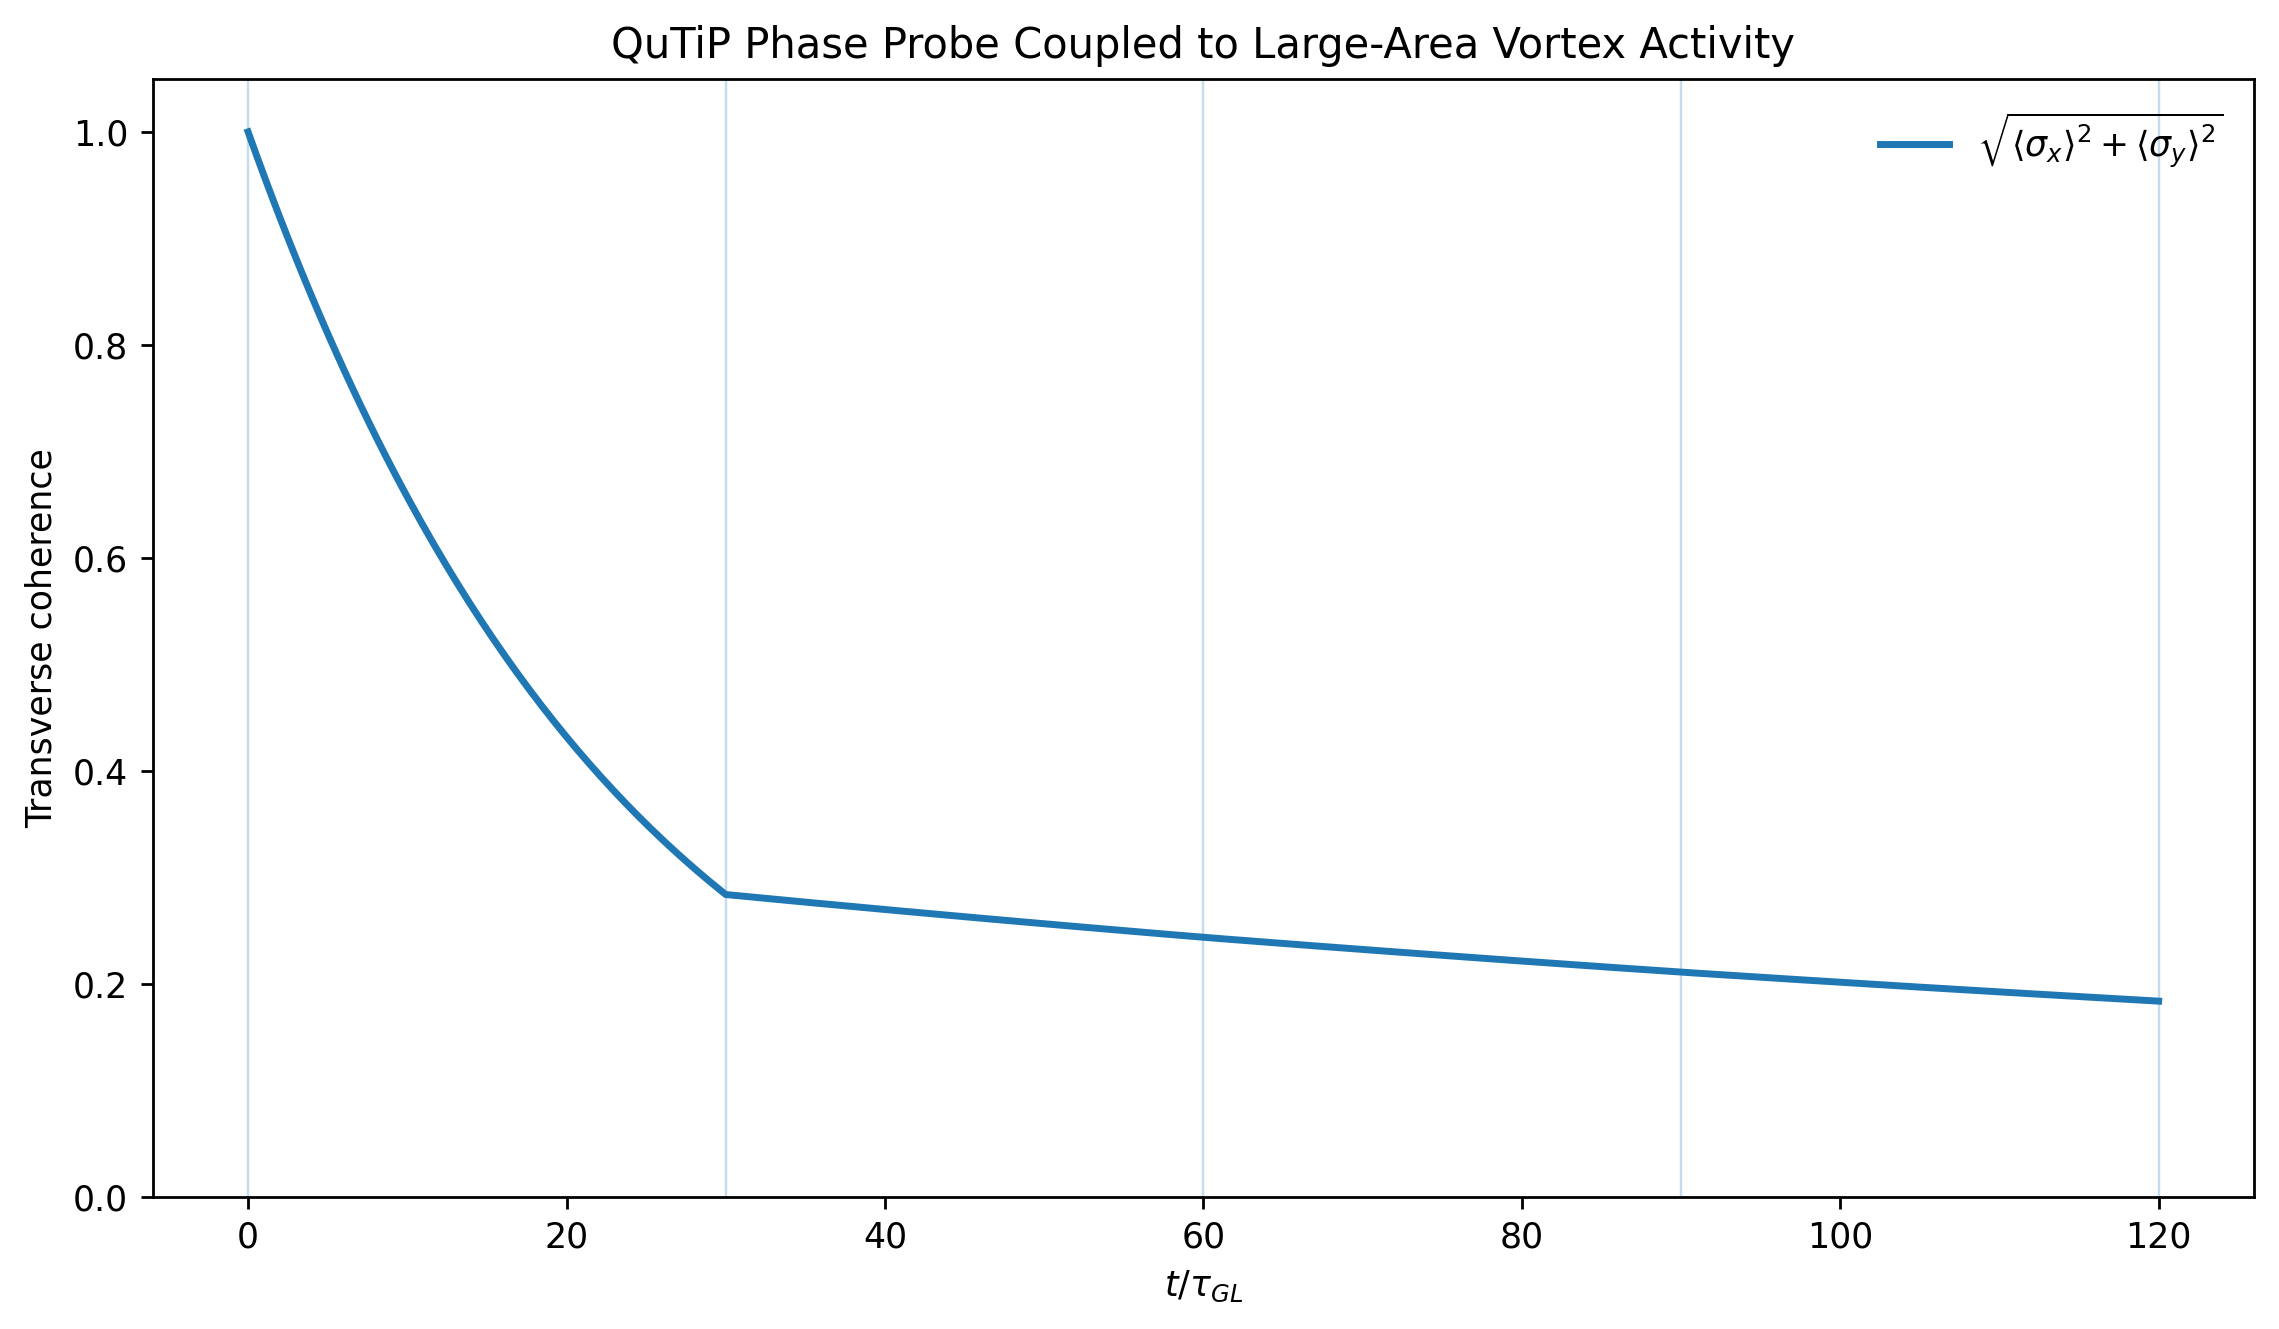

In [2]:
"""Simulate Abrikosov vortex relaxation in a 1 mm superconducting film."""

import functools
import http.server
import threading
import time
from pathlib import Path

import cupy as cp
import k3d
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from IPython.display import HTML, display
from k3d import matplotlib_color_maps


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------

"""
The physical film is 1 mm by 1 mm. The TDGL solver still operates in
coherence-length units, so all physical dimensions are converted to xi
internally and converted back to micrometers for plotting and K3D.
"""
FILM_WIDTH_UM = 1000.0
FILM_HEIGHT_UM = 1000.0

"""
This is an effective Ginzburg-Landau coherence length for the mesoscopic
simulation. A 1.0 um value keeps a 1 mm film numerically tractable on a
Colab GPU and gives a nominal vortex-core diameter near 2 um.
"""
COHERENCE_LENGTH_UM = 1.0

"""
The residual perpendicular field controls the expected vortex population.
At 0.75 uT over 1 mm^2, the magnetic flux corresponds to about 363 flux
quanta before finite-size and relaxation effects are considered.
"""
APPLIED_FIELD_UT = 0.75

# Grid resolution.
GRID_NX = 640
GRID_NY = 640

# TDGL dynamics.
TDGL_U = 5.79
TIME_STEP = 0.030
NUM_STEPS = 4000
SNAPSHOT_COUNT = 5
STATUS_INTERVAL = 500
STABILITY_LIMIT = 5.0

# Initial vortex population.
SEED_VORTEX_COUNT = None
VORTEX_EDGE_MARGIN_UM = 8.0
MINIMUM_VORTEX_SEPARATION_UM = 12.0
VORTEX_CORE_SCALE_XI = 1.0
INITIAL_AMPLITUDE_NOISE = 0.010
RNG_SEED = 17

# Optional Langevin perturbation.
THERMAL_NOISE_STRENGTH = 0.0
THERMAL_NOISE_INTERVAL = 10

# Vortex detection.
MINIMUM_CORE_CONTRAST_FOR_MARKER = 0.035

# Two-dimensional plotting.
FIGURE_DPI = 250
FIGURE_WIDTH_INCHES = 14.0
FIGURE_HEIGHT_INCHES = 8.0
VORTEX_MARKER_SIZE = 8.0
HEATMAP_CMAP = "magma"

# QuTiP auxiliary phase-coherence probe.
RUN_QUTIP_PROBE = True
QUTIP_BASE_DEPHASING = 0.002
QUTIP_VORTEX_DEPHASING_SCALE = 0.040
QUTIP_PROBE_DETUNING = 0.0
QUTIP_POINTS_PER_INTERVAL = 120

"""
Each TDGL state is serialized into its own standalone K3D HTML document.
A small HTML selector switches among those documents, which avoids the
K3D time-series trait path that previously omitted later snapshots.
"""
RUN_K3D_VISUALIZATION = True
K3D_VISUALIZATION_STRIDE = 2
K3D_HEIGHT_PIXELS = 720
K3D_IFRAME_HEIGHT_PIXELS = 820
K3D_STANDALONE_DIRECTORY = Path(
    "/content/abrikosov_1mm_k3d_snapshots"
)
K3D_SERVER_PORT = 0
K3D_SNAPSHOT_COMPRESSION_LEVEL = 6

"""
The actual superconducting film may be far thinner than its lateral size.
The z scale is exaggerated only in the 3D rendering so the film and
substrate stay visible beside a 1 mm by 1 mm lateral footprint.
"""
PHYSICAL_FILM_THICKNESS_UM = 0.10
PHYSICAL_SUBSTRATE_THICKNESS_UM = 20.0
K3D_Z_EXAGGERATION = 12.0
K3D_SURFACE_OFFSET_UM = 0.10

# Vortex glyphs stay close to the physical core scale.
K3D_VORTEX_POINT_SIZE_UM = 2.5 * COHERENCE_LENGTH_UM
K3D_BACKGROUND_COLOR = 0xFFFFFF
K3D_GRID_COLOR = 0xD8D8D8
K3D_LABEL_COLOR = 0x303030
K3D_FILM_BASE_COLOR = 0x7D828A
K3D_SUBSTRATE_COLOR = 0xD9DDE3
K3D_POSITIVE_VORTEX_COLOR = 0x00B8D9
K3D_NEGATIVE_VORTEX_COLOR = 0xFF5A5F

# Physical constants and derived dimensions.
FLUX_QUANTUM_WB = 2.067833848e-15
COHERENCE_LENGTH_M = COHERENCE_LENGTH_UM * 1.0e-6

FILM_WIDTH_XI = FILM_WIDTH_UM / COHERENCE_LENGTH_UM
FILM_HEIGHT_XI = FILM_HEIGHT_UM / COHERENCE_LENGTH_UM

VORTEX_EDGE_MARGIN_XI = VORTEX_EDGE_MARGIN_UM / COHERENCE_LENGTH_UM
MINIMUM_VORTEX_SEPARATION_XI = (
    MINIMUM_VORTEX_SEPARATION_UM / COHERENCE_LENGTH_UM
)

APPLIED_FIELD_T = APPLIED_FIELD_UT * 1.0e-6
APPLIED_FIELD = (
    2.0
    * np.pi
    * COHERENCE_LENGTH_M**2
    * APPLIED_FIELD_T
    / FLUX_QUANTUM_WB
)

mpl.rcParams["figure.dpi"] = FIGURE_DPI
mpl.rcParams["savefig.dpi"] = FIGURE_DPI
mpl.rcParams["axes.grid"] = False
mpl.rcParams["font.size"] = 10


# ------------------------------------------------------------
# ENVIRONMENT AND PHYSICAL-SCALE CHECKS
# ------------------------------------------------------------

def verify_environment():
    """Verify the GPU environment and report the large-sample scale."""
    if cp.cuda.runtime.getDeviceCount() < 1:
        raise RuntimeError(
            "No CUDA device was detected. Select a GPU runtime in Colab."
        )

    properties = cp.cuda.runtime.getDeviceProperties(0)
    device_name = properties["name"]

    if isinstance(device_name, bytes):
        device_name = device_name.decode("utf-8")

    free_memory, total_memory = cp.cuda.runtime.memGetInfo()

    dx_xi = FILM_WIDTH_XI / (GRID_NX - 1)
    dy_xi = FILM_HEIGHT_XI / (GRID_NY - 1)

    expected_flux_quanta = (
        APPLIED_FIELD_T
        * FILM_WIDTH_UM
        * 1.0e-6
        * FILM_HEIGHT_UM
        * 1.0e-6
        / FLUX_QUANTUM_WB
    )

    triangular_spacing_um = np.sqrt(
        2.0
        * FLUX_QUANTUM_WB
        / (
            np.sqrt(3.0)
            * max(abs(APPLIED_FIELD_T), np.finfo(float).tiny)
        )
    ) * 1.0e6

    print("Large-area superconducting-film configuration")
    print(f"  GPU:                    {device_name}")
    print(f"  CuPy:                   {cp.__version__}")
    print(f"  QuTiP:                  {qt.__version__}")
    print(f"  K3D:                    {k3d.__version__}")
    print(f"  Free VRAM:              {free_memory / 2**30:.2f} GiB")
    print(f"  Total VRAM:             {total_memory / 2**30:.2f} GiB")
    print(f"  Film:                    {FILM_WIDTH_UM:.1f} x "
          f"{FILM_HEIGHT_UM:.1f} um")
    print(f"  Film area:               "
          f"{FILM_WIDTH_UM * FILM_HEIGHT_UM / 1.0e6:.3f} mm^2")
    print(f"  Effective xi:            {COHERENCE_LENGTH_UM:.3f} um")
    print(f"  Nominal core diameter:   "
          f"{2.0 * COHERENCE_LENGTH_UM:.3f} um")
    print(f"  Applied field:           {APPLIED_FIELD_UT:.3f} uT")
    print(f"  Expected flux quanta:    {expected_flux_quanta:.1f}")
    print(f"  Triangular spacing:      {triangular_spacing_um:.1f} um")
    print(f"  Grid:                    {GRID_NX} x {GRID_NY}")
    print(f"  dx, dy:                  {dx_xi:.3f}, {dy_xi:.3f} xi")
    print(f"  Physical dx, dy:         "
          f"{dx_xi * COHERENCE_LENGTH_UM:.3f}, "
          f"{dy_xi * COHERENCE_LENGTH_UM:.3f} um")
    print()

    if max(dx_xi, dy_xi) > 2.0:
        print(
            "WARNING: the TDGL grid is coarse compared with xi. "
            "Increase GRID_NX and GRID_NY for sharper microscopic cores."
        )
        print()


# ------------------------------------------------------------
# GRID AND GAUGE LINKS
# ------------------------------------------------------------

def build_grid_and_links():
    """Construct the 1 mm film grid and magnetic link variables."""
    x = cp.linspace(
        -0.5 * FILM_WIDTH_XI,
        0.5 * FILM_WIDTH_XI,
        GRID_NX,
        dtype=cp.float32,
    )
    y = cp.linspace(
        -0.5 * FILM_HEIGHT_XI,
        0.5 * FILM_HEIGHT_XI,
        GRID_NY,
        dtype=cp.float32,
    )

    x_grid, y_grid = cp.meshgrid(x, y)

    dx = float(FILM_WIDTH_XI / (GRID_NX - 1))
    dy = float(FILM_HEIGHT_XI / (GRID_NY - 1))

    vector_potential_x = -0.5 * APPLIED_FIELD * y_grid
    vector_potential_y = 0.5 * APPLIED_FIELD * x_grid

    link_x = cp.exp(
        -1j * vector_potential_x * dx
    ).astype(cp.complex64)

    link_y = cp.exp(
        -1j * vector_potential_y * dy
    ).astype(cp.complex64)

    return x, y, x_grid, y_grid, dx, dy, link_x, link_y


# ------------------------------------------------------------
# INITIAL ABRIKOSOV STATE
# ------------------------------------------------------------

def estimate_flux_vortex_count():
    """Estimate the vortex count from the physical flux through 1 mm^2."""
    area_m2 = (
        FILM_WIDTH_UM * 1.0e-6
        * FILM_HEIGHT_UM * 1.0e-6
    )
    flux_quanta = abs(APPLIED_FIELD_T) * area_m2 / FLUX_QUANTUM_WB

    return max(1, int(round(flux_quanta)))


def generate_vortex_positions(vortex_count):
    """Generate separated initial vortex centers over the large film."""
    rng = np.random.default_rng(RNG_SEED)

    x_low = -0.5 * FILM_WIDTH_XI + VORTEX_EDGE_MARGIN_XI
    x_high = 0.5 * FILM_WIDTH_XI - VORTEX_EDGE_MARGIN_XI
    y_low = -0.5 * FILM_HEIGHT_XI + VORTEX_EDGE_MARGIN_XI
    y_high = 0.5 * FILM_HEIGHT_XI - VORTEX_EDGE_MARGIN_XI

    positions = []
    maximum_attempts = 1_000_000

    for _ in range(maximum_attempts):
        candidate = np.array(
            [
                rng.uniform(x_low, x_high),
                rng.uniform(y_low, y_high),
            ],
            dtype=np.float32,
        )

        accepted = True

        for existing in positions:
            separation = np.linalg.norm(candidate - existing)

            if separation < MINIMUM_VORTEX_SEPARATION_XI:
                accepted = False
                break

        if accepted:
            positions.append(candidate)

        if len(positions) >= vortex_count:
            break

    if len(positions) < vortex_count:
        raise RuntimeError(
            "Vortex placement exhausted its attempts. Reduce "
            "MINIMUM_VORTEX_SEPARATION_UM or APPLIED_FIELD_UT."
        )

    return np.asarray(positions, dtype=np.float32)


def initialize_order_parameter(x_grid, y_grid, vortex_positions):
    """Imprint the initial vortex population into the complex GL field."""
    cp.random.seed(RNG_SEED)

    psi = cp.ones(
        (GRID_NY, GRID_NX),
        dtype=cp.complex64,
    )

    winding_sign = 1.0 if APPLIED_FIELD >= 0.0 else -1.0
    core_denominator = np.sqrt(2.0) * VORTEX_CORE_SCALE_XI

    print(f"Imprinting {len(vortex_positions)} initial vortices...")

    for index, (vortex_x, vortex_y) in enumerate(vortex_positions):
        delta_x = x_grid - float(vortex_x)
        delta_y = y_grid - float(vortex_y)

        radius = cp.sqrt(delta_x**2 + delta_y**2)
        angle = cp.arctan2(delta_y, delta_x)

        core_profile = cp.tanh(
            radius / core_denominator
        ).astype(cp.float32)

        phase_factor = cp.exp(
            1j * winding_sign * angle
        ).astype(cp.complex64)

        psi *= core_profile * phase_factor

        if (index + 1) % 100 == 0:
            print(
                f"  Imprinted {index + 1}/{len(vortex_positions)} vortices"
            )

    random_amplitude = cp.random.standard_normal(
        psi.shape
    ).astype(cp.float32)

    psi *= (
        1.0
        + INITIAL_AMPLITUDE_NOISE * random_amplitude
    ).astype(cp.float32)

    print()
    return psi


# ------------------------------------------------------------
# GAUGE-COVARIANT ADJACENCY OPERATOR
# ------------------------------------------------------------

def covariant_laplacian(psi, link_x, link_y, dx, dy):
    """Apply the four-neighbor gauge-covariant graph Laplacian."""
    east = cp.empty_like(psi)
    west = cp.empty_like(psi)
    north = cp.empty_like(psi)
    south = cp.empty_like(psi)

    east[:, :-1] = link_x[:, :-1] * psi[:, 1:]
    east[:, -1] = psi[:, -1]

    west[:, 1:] = cp.conj(link_x[:, :-1]) * psi[:, :-1]
    west[:, 0] = psi[:, 0]

    north[:-1, :] = link_y[:-1, :] * psi[1:, :]
    north[-1, :] = psi[-1, :]

    south[1:, :] = cp.conj(link_y[:-1, :]) * psi[:-1, :]
    south[0, :] = psi[0, :]

    return (
        (east + west - 2.0 * psi) / (dx * dx)
        + (north + south - 2.0 * psi) / (dy * dy)
    )


# ------------------------------------------------------------
# TDGL EVOLUTION
# ------------------------------------------------------------

def run_tdgl_simulation(psi, link_x, link_y, dx, dy):
    """Evolve TDGL and retain five explicitly separated time states."""
    snapshot_steps = np.linspace(
        0,
        NUM_STEPS,
        SNAPSHOT_COUNT,
        dtype=int,
    )

    snapshot_lookup = {
        int(step): index
        for index, step in enumerate(snapshot_steps)
    }

    snapshots = [None] * SNAPSHOT_COUNT
    snapshot_times = np.zeros(SNAPSHOT_COUNT, dtype=float)

    effective_dt = TIME_STEP / TDGL_U
    noise_scale = (
        THERMAL_NOISE_STRENGTH * np.sqrt(effective_dt)
    )

    start_time = time.perf_counter()

    for step in range(NUM_STEPS + 1):
        if step in snapshot_lookup:
            snapshot_index = snapshot_lookup[step]
            snapshots[snapshot_index] = cp.asnumpy(psi)
            snapshot_times[snapshot_index] = step * TIME_STEP

        if step >= NUM_STEPS:
            break

        laplacian = covariant_laplacian(
            psi,
            link_x,
            link_y,
            dx,
            dy,
        )

        amplitude_squared = cp.abs(psi) ** 2
        local_gl_term = (
            1.0 - amplitude_squared
        ) * psi

        psi += effective_dt * (
            laplacian + local_gl_term
        )

        if (
            THERMAL_NOISE_STRENGTH > 0.0
            and step % THERMAL_NOISE_INTERVAL == 0
        ):
            noise_real = cp.random.standard_normal(
                psi.shape
            ).astype(cp.float32)

            noise_imag = cp.random.standard_normal(
                psi.shape
            ).astype(cp.float32)

            psi += noise_scale * (
                noise_real + 1j * noise_imag
            )

        if step > 0 and step % STATUS_INTERVAL == 0:
            maximum = float(
                cp.max(cp.abs(psi)).get()
            )

            elapsed = time.perf_counter() - start_time

            print(
                f"Step {step:5d}/{NUM_STEPS} | "
                f"t/tau_GL = {step * TIME_STEP:8.2f} | "
                f"max|psi| = {maximum:.4f} | "
                f"elapsed = {elapsed:.1f} s"
            )

            if (
                np.isfinite(maximum) is False
                or maximum > STABILITY_LIMIT
            ):
                raise FloatingPointError(
                    "TDGL became unstable. Reduce TIME_STEP."
                )

    cp.cuda.Stream.null.synchronize()

    print()
    print(
        f"TDGL GPU runtime: "
        f"{time.perf_counter() - start_time:.2f} s"
    )
    print()

    return snapshots, snapshot_times


# ------------------------------------------------------------
# TOPOLOGICAL VORTEX DETECTION
# ------------------------------------------------------------

def wrap_phase(delta_phase):
    """Wrap a phase difference onto [-pi, pi)."""
    return (
        delta_phase + np.pi
    ) % (2.0 * np.pi) - np.pi


def detect_vortices(psi, x_coordinates, y_coordinates):
    """Locate integer phase winding on every lattice plaquette."""
    phase = np.angle(psi)

    phase_00 = phase[:-1, :-1]
    phase_01 = phase[:-1, 1:]
    phase_11 = phase[1:, 1:]
    phase_10 = phase[1:, :-1]

    winding = (
        wrap_phase(phase_01 - phase_00)
        + wrap_phase(phase_11 - phase_01)
        + wrap_phase(phase_10 - phase_11)
        + wrap_phase(phase_00 - phase_10)
    ) / (2.0 * np.pi)

    charge = np.rint(winding).astype(np.int8)

    x_centers = 0.5 * (
        x_coordinates[:-1] + x_coordinates[1:]
    )
    y_centers = 0.5 * (
        y_coordinates[:-1] + y_coordinates[1:]
    )

    x_mesh, y_mesh = np.meshgrid(
        x_centers,
        y_centers,
    )

    depletion = np.clip(
        1.0 - np.abs(psi) ** 2,
        0.0,
        1.0,
    )

    plaquette_contrast = 0.25 * (
        depletion[:-1, :-1]
        + depletion[:-1, 1:]
        + depletion[1:, :-1]
        + depletion[1:, 1:]
    )

    positive_mask = (
        charge >= 1
    ) & (
        plaquette_contrast
        >= MINIMUM_CORE_CONTRAST_FOR_MARKER
    )

    negative_mask = (
        charge <= -1
    ) & (
        plaquette_contrast
        >= MINIMUM_CORE_CONTRAST_FOR_MARKER
    )

    positive_positions = np.column_stack(
        (
            x_mesh[positive_mask],
            y_mesh[positive_mask],
        )
    ).astype(np.float32)

    negative_positions = np.column_stack(
        (
            x_mesh[negative_mask],
            y_mesh[negative_mask],
        )
    ).astype(np.float32)

    return positive_positions, negative_positions


# ------------------------------------------------------------
# TWO-DIMENSIONAL SNAPSHOTS
# ------------------------------------------------------------

def plot_vortex_snapshots(
    snapshots,
    snapshot_times,
    x_coordinates,
    y_coordinates,
):
    """Render the five large-area vortex heat maps in micrometers."""
    figure, axes = plt.subplots(
        2,
        3,
        figsize=(
            FIGURE_WIDTH_INCHES,
            FIGURE_HEIGHT_INCHES,
        ),
        constrained_layout=True,
    )

    axes_flat = axes.ravel()

    extent = (
        x_coordinates[0] * COHERENCE_LENGTH_UM,
        x_coordinates[-1] * COHERENCE_LENGTH_UM,
        y_coordinates[0] * COHERENCE_LENGTH_UM,
        y_coordinates[-1] * COHERENCE_LENGTH_UM,
    )

    image = None

    for index, (
        snapshot,
        snapshot_time,
    ) in enumerate(
        zip(snapshots, snapshot_times)
    ):
        axis = axes_flat[index]

        depletion = np.clip(
            1.0 - np.abs(snapshot) ** 2,
            0.0,
            1.0,
        )

        positive, negative = detect_vortices(
            snapshot,
            x_coordinates,
            y_coordinates,
        )

        image = axis.imshow(
            depletion,
            origin="lower",
            extent=extent,
            cmap=HEATMAP_CMAP,
            vmin=0.0,
            vmax=1.0,
            interpolation="bilinear",
            aspect="equal",
        )

        if len(positive) > 0:
            axis.scatter(
                positive[:, 0] * COHERENCE_LENGTH_UM,
                positive[:, 1] * COHERENCE_LENGTH_UM,
                s=VORTEX_MARKER_SIZE,
                facecolors="none",
                edgecolors="white",
                linewidths=0.45,
            )

        if len(negative) > 0:
            axis.scatter(
                negative[:, 0] * COHERENCE_LENGTH_UM,
                negative[:, 1] * COHERENCE_LENGTH_UM,
                s=VORTEX_MARKER_SIZE,
                marker="x",
                linewidths=0.45,
            )

        axis.set_title(
            rf"$t/\tau_{{GL}}={snapshot_time:.1f}$"
            f" | vortices={len(positive)}"
        )

        axis.set_xlabel(r"$x\;(\mu\mathrm{m})$")
        axis.set_ylabel(r"$y\;(\mu\mathrm{m})$")

    axes_flat[-1].axis("off")

    colorbar = figure.colorbar(
        image,
        ax=axes_flat.tolist(),
        shrink=0.90,
        pad=0.02,
    )

    colorbar.set_label(
        r"Condensate depletion $1-|\psi|^2$"
    )

    figure.suptitle(
        "Abrikosov Vortex Relaxation on a 1 mm × 1 mm "
        "Superconducting Thin Film",
        fontsize=14,
    )

    plt.show()


# ------------------------------------------------------------
# K3D STANDALONE MULTI-SNAPSHOT VIEWER
# ------------------------------------------------------------

K3D_HTTP_SERVER = None
K3D_HTTP_THREAD = None


def choose_k3d_sample_indices(length):
    """Return downsampled K3D indices and retain the final point."""
    stride = max(1, int(K3D_VISUALIZATION_STRIDE))

    indices = np.arange(
        0,
        length,
        stride,
        dtype=np.int32,
    )

    if indices[-1] != length - 1:
        indices = np.append(
            indices,
            length - 1,
        )

    return indices


def create_box_geometry(extents, center):
    """Create a closed rectangular prism for K3D."""
    extent_x, extent_y, extent_z = [
        float(value) for value in extents
    ]
    center_x, center_y, center_z = [
        float(value) for value in center
    ]

    half_x = 0.5 * extent_x
    half_y = 0.5 * extent_y
    half_z = 0.5 * extent_z

    vertices = np.array(
        [
            [center_x - half_x, center_y - half_y, center_z - half_z],
            [center_x + half_x, center_y - half_y, center_z - half_z],
            [center_x + half_x, center_y + half_y, center_z - half_z],
            [center_x - half_x, center_y + half_y, center_z - half_z],
            [center_x - half_x, center_y - half_y, center_z + half_z],
            [center_x + half_x, center_y - half_y, center_z + half_z],
            [center_x + half_x, center_y + half_y, center_z + half_z],
            [center_x - half_x, center_y + half_y, center_z + half_z],
        ],
        dtype=np.float32,
    )

    indices = np.array(
        [
            [0, 2, 1],
            [0, 3, 2],
            [4, 5, 6],
            [4, 6, 7],
            [0, 1, 5],
            [0, 5, 4],
            [1, 2, 6],
            [1, 6, 5],
            [2, 3, 7],
            [2, 7, 6],
            [3, 0, 4],
            [3, 4, 7],
        ],
        dtype=np.uint32,
    )

    return (
        np.ascontiguousarray(vertices),
        np.ascontiguousarray(indices),
    )


def build_single_k3d_scene(
    snapshot,
    snapshot_time,
    x_coordinates,
    y_coordinates,
):
    """Build one complete standalone K3D scene for one TDGL state."""
    x_indices = choose_k3d_sample_indices(
        len(x_coordinates)
    )
    y_indices = choose_k3d_sample_indices(
        len(y_coordinates)
    )

    x_um = (
        x_coordinates[x_indices]
        * COHERENCE_LENGTH_UM
    )
    y_um = (
        y_coordinates[y_indices]
        * COHERENCE_LENGTH_UM
    )

    depletion = np.clip(
        1.0 - np.abs(snapshot) ** 2,
        0.0,
        1.0,
    ).astype(np.float32)

    sampled_depletion = np.ascontiguousarray(
        depletion[
            np.ix_(y_indices, x_indices)
        ],
        dtype=np.float32,
    )

    positive, negative = detect_vortices(
        snapshot,
        x_coordinates,
        y_coordinates,
    )

    physical_film_z = (
        PHYSICAL_FILM_THICKNESS_UM
        * K3D_Z_EXAGGERATION
    )
    substrate_z = (
        PHYSICAL_SUBSTRATE_THICKNESS_UM
        * K3D_Z_EXAGGERATION
    )

    film_top_z = 0.5 * physical_film_z
    surface_z = (
        film_top_z
        + K3D_SURFACE_OFFSET_UM
    )
    substrate_center_z = -(
        0.5 * physical_film_z
        + 0.5 * substrate_z
    )

    substrate_vertices, substrate_indices = (
        create_box_geometry(
            extents=(
                FILM_WIDTH_UM,
                FILM_HEIGHT_UM,
                substrate_z,
            ),
            center=(
                0.0,
                0.0,
                substrate_center_z,
            ),
        )
    )

    film_vertices, film_indices = (
        create_box_geometry(
            extents=(
                FILM_WIDTH_UM,
                FILM_HEIGHT_UM,
                physical_film_z,
            ),
            center=(0.0, 0.0, 0.0),
        )
    )

    surface_heights = np.full(
        sampled_depletion.shape,
        surface_z,
        dtype=np.float32,
    )

    plot = k3d.plot(
        height=K3D_HEIGHT_PIXELS,
        background_color=K3D_BACKGROUND_COLOR,
        grid_color=K3D_GRID_COLOR,
        label_color=K3D_LABEL_COLOR,
        grid_visible=True,
        grid_auto_fit=False,
        camera_auto_fit=False,
        grid=(
            -0.55 * FILM_WIDTH_UM,
            -0.55 * FILM_HEIGHT_UM,
            -substrate_z - 10.0,
            0.55 * FILM_WIDTH_UM,
            0.55 * FILM_HEIGHT_UM,
            max(40.0, 6.0 * physical_film_z),
        ),
        axes=[
            "x (um)",
            "y (um)",
            "visual z (um)",
        ],
        antialias=2,
        lighting=1.25,
        menu_visibility=True,
    )

    substrate_mesh = k3d.mesh(
        substrate_vertices,
        substrate_indices,
        color=K3D_SUBSTRATE_COLOR,
        opacity=0.34,
        flat_shading=True,
        side="double",
        name="substrate",
    )

    film_mesh = k3d.mesh(
        film_vertices,
        film_indices,
        color=K3D_FILM_BASE_COLOR,
        opacity=0.94,
        flat_shading=True,
        side="double",
        name="superconducting thin film",
    )

    heatmap_surface = k3d.surface(
        surface_heights,
        xmin=float(x_um[0]),
        xmax=float(x_um[-1]),
        ymin=float(y_um[0]),
        ymax=float(y_um[-1]),
        attribute=sampled_depletion,
        color_map=matplotlib_color_maps.Magma,
        color_range=[0.0, 1.0],
        opacity=1.0,
        flat_shading=True,
        name="condensate depletion 1-|psi|^2",
    )

    plot += substrate_mesh
    plot += film_mesh
    plot += heatmap_surface

    if len(positive) > 0:
        positive_positions = np.column_stack(
            (
                positive[:, 0] * COHERENCE_LENGTH_UM,
                positive[:, 1] * COHERENCE_LENGTH_UM,
                np.full(
                    len(positive),
                    surface_z
                    + 0.5 * K3D_VORTEX_POINT_SIZE_UM,
                    dtype=np.float32,
                ),
            )
        ).astype(np.float32)

        plot += k3d.points(
            positive_positions,
            point_size=K3D_VORTEX_POINT_SIZE_UM,
            color=K3D_POSITIVE_VORTEX_COLOR,
            shader="mesh",
            mesh_detail=1,
            name="Abrikosov vortex cores",
        )

    if len(negative) > 0:
        negative_positions = np.column_stack(
            (
                negative[:, 0] * COHERENCE_LENGTH_UM,
                negative[:, 1] * COHERENCE_LENGTH_UM,
                np.full(
                    len(negative),
                    surface_z
                    + 0.5 * K3D_VORTEX_POINT_SIZE_UM,
                    dtype=np.float32,
                ),
            )
        ).astype(np.float32)

        plot += k3d.points(
            negative_positions,
            point_size=K3D_VORTEX_POINT_SIZE_UM,
            color=K3D_NEGATIVE_VORTEX_COLOR,
            shader="mesh",
            mesh_detail=1,
            name="antivortex cores",
        )

    plot.colorbar_object_id = heatmap_surface.id

    plot.camera = [
        1350.0,
        -1350.0,
        860.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        1.0,
    ]

    return (
        plot,
        len(positive),
        len(negative),
        sampled_depletion.shape,
    )


def write_k3d_snapshot_html(plot, output_path):
    """Serialize one K3D scene into a standalone HTML document."""
    output_path = Path(output_path)

    python_object_count = len(plot.objects)
    binary_scene = plot.get_binary_snapshot_objects()

    serialized_object_count = len(
        binary_scene.get("objects", [])
    )

    if serialized_object_count != python_object_count:
        raise RuntimeError(
            "K3D standalone serialization lost objects. "
            f"Python={python_object_count}, "
            f"serialized={serialized_object_count}."
        )

    html = plot.get_snapshot(
        compression_level=K3D_SNAPSHOT_COMPRESSION_LEVEL
    )

    output_path.write_text(
        html,
        encoding="utf-8",
    )

    if output_path.stat().st_size < 10_000:
        raise RuntimeError(
            "The standalone K3D HTML payload is unexpectedly small."
        )

    return (
        python_object_count,
        serialized_object_count,
        output_path.stat().st_size,
    )


def write_snapshot_selector(output_path, records):
    """Write an HTML controller that exposes all five K3D snapshots."""
    output_path = Path(output_path)

    options = "\n".join(
        (
            f'<option value="{record["filename"]}">'
            f'Snapshot {index + 1} | '
            f't/tau_GL={record["time"]:.2f} | '
            f'vortices={record["vortices"]}'
            f'</option>'
        )
        for index, record in enumerate(records)
    )

    first_file = records[0]["filename"]

    html = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>1 mm Abrikosov Vortex Snapshots</title>
<style>
html, body {{
    margin: 0;
    padding: 0;
    background: #ffffff;
    font-family: Arial, sans-serif;
}}
.toolbar {{
    display: flex;
    flex-wrap: wrap;
    align-items: center;
    gap: 10px;
    padding: 10px 14px;
    background: #f7f7f7;
    border-bottom: 1px solid #d0d0d0;
}}
button, select {{
    font-size: 14px;
    padding: 6px 9px;
}}
iframe {{
    display: block;
    width: 100%;
    height: {K3D_HEIGHT_PIXELS + 40}px;
    border: 0;
}}
</style>
</head>
<body>
<div class="toolbar">
    <strong>1 mm × 1 mm superconducting film</strong>
    <button id="previous" type="button">Previous</button>
    <label for="snapshot-select">Snapshot</label>
    <select id="snapshot-select">
        {options}
    </select>
    <button id="next" type="button">Next</button>
</div>
<iframe
    id="k3d-frame"
    src="{first_file}"
    title="K3D Abrikosov vortex snapshot">
</iframe>
<script>
const selector = document.getElementById("snapshot-select");
const frame = document.getElementById("k3d-frame");
const previous = document.getElementById("previous");
const next = document.getElementById("next");

function loadSelected() {{
    frame.src = selector.value;
}}

selector.addEventListener("change", loadSelected);

previous.addEventListener("click", () => {{
    selector.selectedIndex =
        (selector.selectedIndex - 1 + selector.options.length)
        % selector.options.length;
    loadSelected();
}});

next.addEventListener("click", () => {{
    selector.selectedIndex =
        (selector.selectedIndex + 1)
        % selector.options.length;
    loadSelected();
}});
</script>
</body>
</html>
"""

    output_path.write_text(
        html,
        encoding="utf-8",
    )


class QuietHTTPRequestHandler(
    http.server.SimpleHTTPRequestHandler
):
    """Serve K3D files without access-log noise."""

    def log_message(self, format_string, *args):
        """Suppress HTTP request logging."""
        del format_string, args


def start_k3d_http_server(directory):
    """Start a local HTTP server and return its assigned port."""
    global K3D_HTTP_SERVER
    global K3D_HTTP_THREAD

    if K3D_HTTP_SERVER is not None:
        try:
            K3D_HTTP_SERVER.shutdown()
            K3D_HTTP_SERVER.server_close()
        except OSError:
            pass

    handler = functools.partial(
        QuietHTTPRequestHandler,
        directory=str(Path(directory).resolve()),
    )

    server = http.server.ThreadingHTTPServer(
        ("127.0.0.1", K3D_SERVER_PORT),
        handler,
    )

    thread = threading.Thread(
        target=server.serve_forever,
        daemon=True,
    )
    thread.start()

    K3D_HTTP_SERVER = server
    K3D_HTTP_THREAD = thread

    return server.server_port


def create_k3d_multisnapshot_viewer(
    snapshots,
    snapshot_times,
    x_coordinates,
    y_coordinates,
):
    """Serialize and display all five K3D snapshots explicitly."""
    output_directory = Path(
        K3D_STANDALONE_DIRECTORY
    )
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    records = []

    print("K3D multi-snapshot serialization")
    print()

    for index, (
        snapshot,
        snapshot_time,
    ) in enumerate(
        zip(snapshots, snapshot_times)
    ):
        (
            plot,
            vortex_count,
            antivortex_count,
            heatmap_shape,
        ) = build_single_k3d_scene(
            snapshot,
            snapshot_time,
            x_coordinates,
            y_coordinates,
        )

        filename = (
            f"thin_film_snapshot_{index:02d}.html"
        )
        output_path = (
            output_directory / filename
        )

        (
            python_objects,
            serialized_objects,
            payload_size,
        ) = write_k3d_snapshot_html(
            plot,
            output_path,
        )

        records.append(
            {
                "filename": filename,
                "time": float(snapshot_time),
                "vortices": int(vortex_count),
                "antivortices": int(antivortex_count),
                "python_objects": int(python_objects),
                "serialized_objects": int(serialized_objects),
                "payload_size": int(payload_size),
                "heatmap_shape": tuple(heatmap_shape),
            }
        )

        print(
            f"  Snapshot {index + 1}/{len(snapshots)} | "
            f"t/tau_GL={snapshot_time:.2f} | "
            f"vortices={vortex_count} | "
            f"objects={serialized_objects} | "
            f"heatmap={heatmap_shape[1]}x{heatmap_shape[0]} | "
            f"HTML={payload_size / 2**20:.2f} MiB"
        )

    selector_path = (
        output_directory / "index.html"
    )

    write_snapshot_selector(
        selector_path,
        records,
    )

    port = start_k3d_http_server(
        output_directory
    )

    print()
    print("K3D rendering path")
    print("  Mode: five standalone HTML scenes")
    print("  Snapshot selector: enabled")
    print("  Widget object transport: bypassed")
    print(f"  Directory: {output_directory}")
    print(f"  Port: {port}")
    print()

    try:
        from google.colab import output

        output.serve_kernel_port_as_iframe(
            port,
            path="/index.html",
            height=K3D_IFRAME_HEIGHT_PIXELS,
        )
    except ImportError:
        display(
            HTML(
                f'<a href="http://127.0.0.1:{port}/index.html">'
                "Open the K3D multi-snapshot viewer"
                "</a>"
            )
        )

    return {
        "directory": output_directory,
        "selector": selector_path,
        "records": records,
        "port": port,
        "server": K3D_HTTP_SERVER,
        "thread": K3D_HTTP_THREAD,
    }


# ------------------------------------------------------------
# VORTEX ACTIVITY AND QUTIP PROBE
# ------------------------------------------------------------

def calculate_vortex_activity(
    snapshots,
    snapshot_times,
):
    """Estimate interval vortex activity from condensate rearrangement."""
    raw_activity = []

    for index in range(len(snapshots) - 1):
        first = np.clip(
            1.0 - np.abs(snapshots[index]) ** 2,
            0.0,
            1.0,
        )

        second = np.clip(
            1.0 - np.abs(snapshots[index + 1]) ** 2,
            0.0,
            1.0,
        )

        interval = (
            snapshot_times[index + 1]
            - snapshot_times[index]
        )

        rearrangement = np.mean(
            np.abs(second - first)
        )

        raw_activity.append(
            rearrangement
            / max(
                interval,
                np.finfo(float).eps,
            )
        )

    raw_activity = np.asarray(
        raw_activity,
        dtype=float,
    )

    peak = (
        np.max(raw_activity)
        if len(raw_activity)
        else 0.0
    )

    normalized = (
        raw_activity / peak
        if peak > 0.0
        else np.zeros_like(raw_activity)
    )

    return raw_activity, normalized


def run_qutip_phase_probe(
    snapshots,
    snapshot_times,
):
    """Model reduced phase coherence driven by vortex rearrangement."""
    raw_activity, normalized_activity = (
        calculate_vortex_activity(
            snapshots,
            snapshot_times,
        )
    )

    state_zero = qt.basis(2, 0)
    state_one = qt.basis(2, 1)
    density_matrix = qt.ket2dm(
        (state_zero + state_one).unit()
    )

    sigma_x = qt.sigmax()
    sigma_y = qt.sigmay()
    sigma_z = qt.sigmaz()

    hamiltonian = (
        0.5
        * QUTIP_PROBE_DETUNING
        * sigma_z
    )

    combined_times = []
    combined_x = []
    combined_y = []

    print("QuTiP reduced phase probe")

    for index, activity in enumerate(
        normalized_activity
    ):
        interval_start = snapshot_times[index]
        interval_end = snapshot_times[index + 1]

        gamma_phi = (
            QUTIP_BASE_DEPHASING
            + QUTIP_VORTEX_DEPHASING_SCALE
            * activity
        )

        collapse_operator = (
            np.sqrt(gamma_phi / 2.0)
            * sigma_z
        )

        time_points = np.linspace(
            interval_start,
            interval_end,
            QUTIP_POINTS_PER_INTERVAL,
        )

        result = qt.mesolve(
            hamiltonian,
            density_matrix,
            time_points,
            c_ops=[collapse_operator],
            e_ops=[
                sigma_x,
                sigma_y,
                sigma_z,
            ],
            options={
                "progress_bar": False,
                "store_states": True,
            },
        )

        density_matrix = result.states[-1]

        first_sample = 0 if index == 0 else 1

        combined_times.extend(
            time_points[first_sample:]
        )
        combined_x.extend(
            np.real(
                result.expect[0][first_sample:]
            )
        )
        combined_y.extend(
            np.real(
                result.expect[1][first_sample:]
            )
        )

        print(
            f"  Interval {index + 1}: "
            f"activity={raw_activity[index]:.6e}, "
            f"normalized={activity:.3f}, "
            f"gamma_phi={gamma_phi:.5f}"
        )

    print()

    combined_times = np.asarray(
        combined_times,
        dtype=float,
    )
    combined_x = np.asarray(
        combined_x,
        dtype=float,
    )
    combined_y = np.asarray(
        combined_y,
        dtype=float,
    )

    transverse_coherence = np.sqrt(
        combined_x**2 + combined_y**2
    )

    figure, axis = plt.subplots(
        figsize=(9.0, 5.2),
        constrained_layout=True,
    )

    axis.plot(
        combined_times,
        transverse_coherence,
        linewidth=2.0,
        label=(
            r"$\sqrt{\langle\sigma_x\rangle^2"
            r"+\langle\sigma_y\rangle^2}$"
        ),
    )

    for snapshot_time in snapshot_times:
        axis.axvline(
            snapshot_time,
            linewidth=0.7,
            alpha=0.25,
        )

    axis.set_xlabel(r"$t/\tau_{GL}$")
    axis.set_ylabel("Transverse coherence")
    axis.set_ylim(0.0, 1.05)
    axis.set_title(
        "QuTiP Phase Probe Coupled to Large-Area Vortex Activity"
    )
    axis.legend(frameon=False)

    plt.show()


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    """Run the 1 mm TDGL, five K3D snapshots, and QuTiP probe."""
    verify_environment()

    (
        x_gpu,
        y_gpu,
        x_grid,
        y_grid,
        dx,
        dy,
        link_x,
        link_y,
    ) = build_grid_and_links()

    vortex_count = (
        estimate_flux_vortex_count()
        if SEED_VORTEX_COUNT is None
        else int(SEED_VORTEX_COUNT)
    )

    print(
        f"Initial vortex population requested: {vortex_count}"
    )
    print()

    vortex_positions = generate_vortex_positions(
        vortex_count
    )

    psi = initialize_order_parameter(
        x_grid,
        y_grid,
        vortex_positions,
    )

    snapshots, snapshot_times = (
        run_tdgl_simulation(
            psi,
            link_x,
            link_y,
            dx,
            dy,
        )
    )

    x_coordinates = cp.asnumpy(x_gpu)
    y_coordinates = cp.asnumpy(y_gpu)

    plot_vortex_snapshots(
        snapshots,
        snapshot_times,
        x_coordinates,
        y_coordinates,
    )

    viewer = None

    if RUN_K3D_VISUALIZATION:
        viewer = create_k3d_multisnapshot_viewer(
            snapshots,
            snapshot_times,
            x_coordinates,
            y_coordinates,
        )

    if RUN_QUTIP_PROBE:
        run_qutip_phase_probe(
            snapshots,
            snapshot_times,
        )

    return {
        "snapshots": snapshots,
        "snapshot_times": snapshot_times,
        "viewer": viewer,
    }


RESULTS = main()

Scientific visualization environment
  GPU:        Tesla T4
  CuPy:       13.6.0
  QuTiP:      5.3.1
  K3D:        2.18.1
  Free VRAM:  14.38 GiB
  Total VRAM: 14.56 GiB

CPW simulation configuration
  Grid:               720 x 480
  Footprint:          60.0 um x 40.0 um
  Center width:       10.00 um
  Gap width:          6.00 um
  Coherence length:   150.0 nm
  Nominal core dia.:  0.300 um
  Applied field:      50.0 uT
  Dimensionless B:    0.003418
  Seeded vortices:    41
  dx, dy:             0.556 xi, 0.557 xi
  physical dx, dy:    0.083 um, 0.084 um
  dt/u:               0.001036
  Steps:              6000

Step  1000/6000 | t/tau_GL =    6.00 | max|psi| = 1.0003 | elapsed = 6.5 s
Step  2000/6000 | t/tau_GL =   12.00 | max|psi| = 1.0000 | elapsed = 10.3 s
Step  3000/6000 | t/tau_GL =   18.00 | max|psi| = 1.0000 | elapsed = 13.1 s
Step  4000/6000 | t/tau_GL =   24.00 | max|psi| = 1.0000 | elapsed = 15.4 s
Step  5000/6000 | t/tau_GL =   30.00 | max|psi| = 1.0000 | elapsed = 17.7 s

<IPython.core.display.Javascript object>

QuTiP reduced CPW resonator probe
  Interval 1: activity=4.571266e-03, normalized=1.000, kappa=0.03700
  Interval 2: activity=4.070150e-04, normalized=0.089, kappa=0.00512
  Interval 3: activity=2.367424e-04, normalized=0.052, kappa=0.00381
  Interval 4: activity=2.187043e-04, normalized=0.048, kappa=0.00367



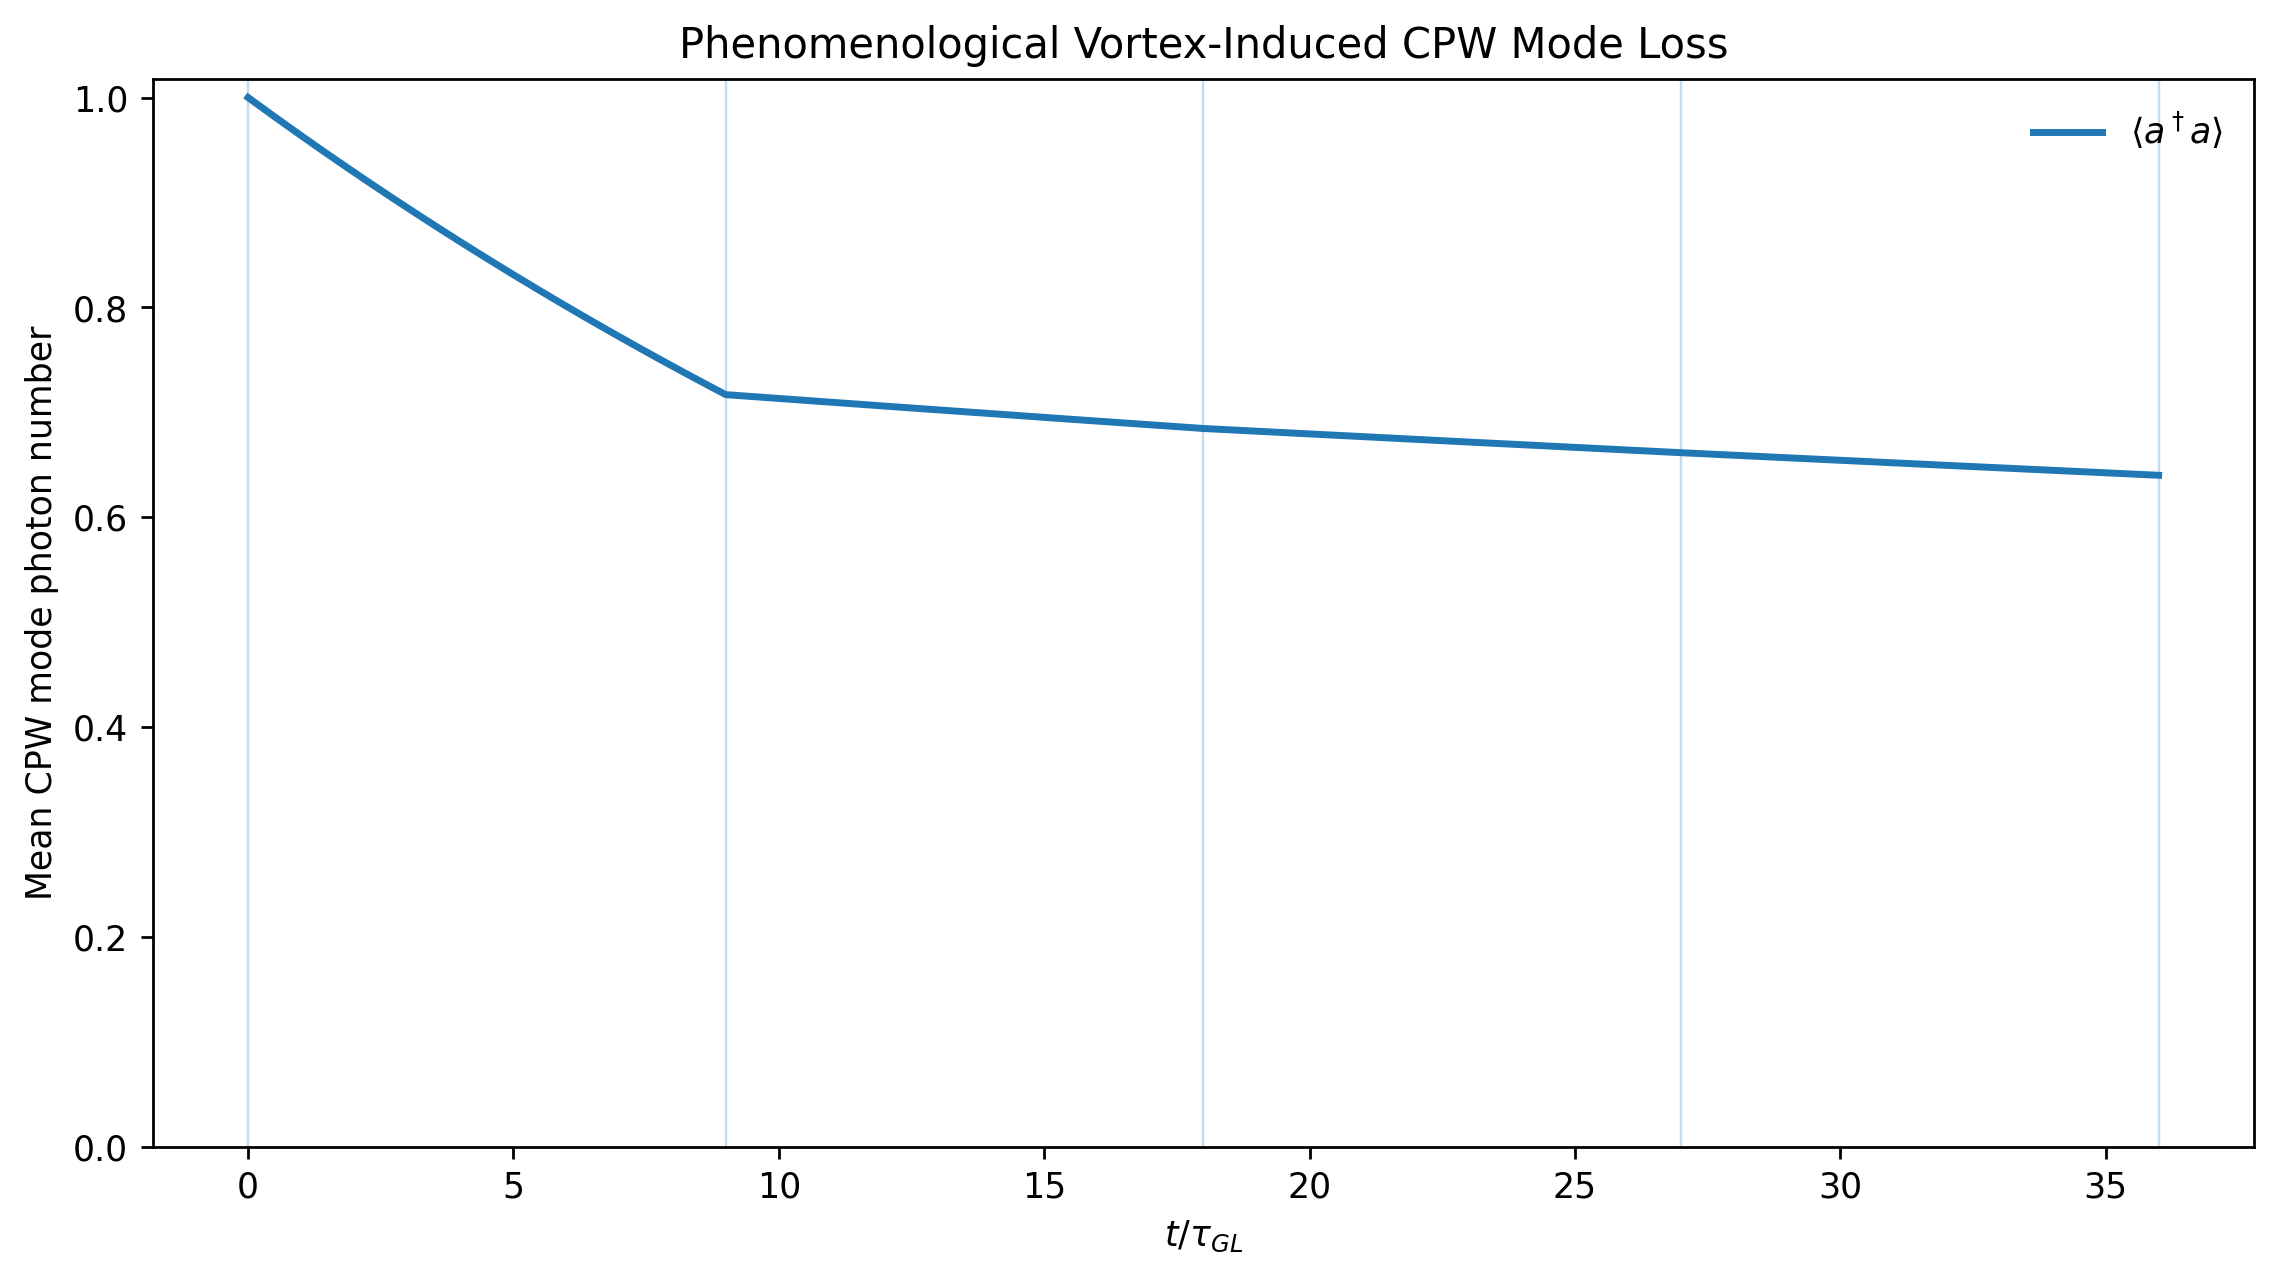

In [3]:
"""GPU TDGL simulation of Abrikosov vortices in a thin-film CPW."""

import http.server
import socket
import socketserver
import threading
import time
from pathlib import Path

import cupy as cp
import k3d
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from k3d import matplotlib_color_maps

try:
    from google.colab import output

    output.enable_custom_widget_manager()
except ImportError:
    pass

if hasattr(k3d, "switch_to_text_protocol"):
    k3d.switch_to_text_protocol()


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------

"""
Physical scale.

The TDGL solver uses coherence-length units internally, then converts the
geometry to micrometers for K3D. A 150 nm effective GL coherence length gives
a vortex-core diameter of order 2 xi ~= 0.30 um, much smaller than a
micrometer-scale CPW center conductor.
"""
COHERENCE_LENGTH_NM = 150.0
FILM_LENGTH_UM = 60.0
FILM_WIDTH_UM = 40.0

# CPW geometry in physical units.
CPW_CENTER_WIDTH_UM = 10.0
CPW_GAP_WIDTH_UM = 6.0

# Thin-film and substrate thicknesses used only by the K3D geometry.
VISUAL_FILM_THICKNESS_NM = 120.0
VISUAL_SUBSTRATE_THICKNESS_UM = 1.20

"""
Perpendicular residual/trapping field in microtesla.

A tens-of-microtesla field gives a sparse population of trapped vortices
across this footprint instead of thousands of vortices at millitesla fields.
"""
APPLIED_FIELD_UT = 50.0

# TDGL grid. This resolution gives approximately 0.6 xi per lattice spacing
# with the default physical dimensions.
GRID_NX = 720
GRID_NY = 480

TDGL_U = 5.79
TIME_STEP = 0.006
NUM_STEPS = 6000
SNAPSHOT_COUNT = 5
STATUS_INTERVAL = 1000
STABILITY_LIMIT = 5.0

# Initial vortex population.
SEED_VORTEX_COUNT = None
VORTEX_EDGE_MARGIN_UM = 0.45
MINIMUM_VORTEX_SEPARATION_UM = 1.00
VORTEX_CORE_SCALE_XI = 1.0
INITIAL_AMPLITUDE_NOISE = 0.012
RNG_SEED = 17

# Derived unit conversions used by the dimensionless TDGL solver.
FLUX_QUANTUM_WB = 2.067833848e-15
COHERENCE_LENGTH_UM = COHERENCE_LENGTH_NM * 1.0e-3
COHERENCE_LENGTH_M = COHERENCE_LENGTH_NM * 1.0e-9

FILM_LENGTH_XI = FILM_LENGTH_UM / COHERENCE_LENGTH_UM
FILM_WIDTH_XI = FILM_WIDTH_UM / COHERENCE_LENGTH_UM
CPW_CENTER_WIDTH_XI = CPW_CENTER_WIDTH_UM / COHERENCE_LENGTH_UM
CPW_GAP_WIDTH_XI = CPW_GAP_WIDTH_UM / COHERENCE_LENGTH_UM
VORTEX_EDGE_MARGIN_XI = VORTEX_EDGE_MARGIN_UM / COHERENCE_LENGTH_UM
MINIMUM_VORTEX_SEPARATION_XI = (
    MINIMUM_VORTEX_SEPARATION_UM / COHERENCE_LENGTH_UM
)

VISUAL_FILM_THICKNESS_UM = VISUAL_FILM_THICKNESS_NM * 1.0e-3
VISUAL_FILM_THICKNESS_XI = (
    VISUAL_FILM_THICKNESS_UM / COHERENCE_LENGTH_UM
)
VISUAL_SUBSTRATE_THICKNESS_XI = (
    VISUAL_SUBSTRATE_THICKNESS_UM / COHERENCE_LENGTH_UM
)

# Dimensionless magnetic field used by the gauge links.
APPLIED_FIELD_T = APPLIED_FIELD_UT * 1.0e-6
APPLIED_FIELD = (
    2.0
    * np.pi
    * COHERENCE_LENGTH_M**2
    * APPLIED_FIELD_T
    / FLUX_QUANTUM_WB
)

# Optional Langevin perturbation.
THERMAL_NOISE_STRENGTH = 0.0
THERMAL_NOISE_INTERVAL = 10

# Vortex detection.
MINIMUM_CORE_CONTRAST_FOR_MARKER = 0.08

"""
K3D standalone display. This bypasses Colab's K3D widget transport.

The K3D scene uses micrometers rather than xi. The vortex glyph diameter is
kept close to the physical 2 xi core diameter instead of exaggerating it to
the scale of the CPW conductors.
"""
K3D_VISUALIZATION_STRIDE = 2
K3D_HEIGHT_PIXELS = 700
K3D_VORTEX_POINT_SIZE_UM = 2.0 * COHERENCE_LENGTH_UM
K3D_FLUX_LINE_WIDTH_UM = 0.055
K3D_FLUX_TUBE_HEIGHT_UM = 0.90
K3D_HEATMAP_Z_OFFSET_UM = 0.012
K3D_STANDALONE_DIRECTORY = Path("/content/cpw_k3d_physical_scale")
K3D_SERVER_PORT = 0
K3D_IFRAME_HEIGHT_PIXELS = 780

K3D_BACKGROUND_COLOR = 0xFFFFFF
K3D_GRID_COLOR = 0xD9D9D9
K3D_LABEL_COLOR = 0x333333
K3D_SUBSTRATE_COLOR = 0xD6DCE4
K3D_METAL_SIDE_COLOR = 0xA7AFB8
K3D_VORTEX_COLOR = 0x00A6FF
K3D_ANTIVORTEX_COLOR = 0xFF4D4D

# Optional reduced QuTiP resonator model.
RUN_QUTIP_RESONATOR_PROBE = True
QUTIP_CAVITY_LEVELS = 8
QUTIP_RESONATOR_OMEGA = 0.25
QUTIP_BASE_LOSS_RATE = 0.002
QUTIP_VORTEX_LOSS_SCALE = 0.035
QUTIP_POINTS_PER_INTERVAL = 120

FIGURE_DPI = 250
mpl.rcParams["figure.dpi"] = FIGURE_DPI
mpl.rcParams["savefig.dpi"] = FIGURE_DPI


# ------------------------------------------------------------
# ENVIRONMENT AND CPW GRID
# ------------------------------------------------------------


def verify_environment():
    """Verify CUDA and report package versions."""
    if cp.cuda.runtime.getDeviceCount() < 1:
        raise RuntimeError("No CUDA device detected. Select a GPU runtime.")

    properties = cp.cuda.runtime.getDeviceProperties(0)
    device_name = properties["name"]
    if isinstance(device_name, bytes):
        device_name = device_name.decode("utf-8")

    free_memory, total_memory = cp.cuda.runtime.memGetInfo()
    print("Scientific visualization environment")
    print(f"  GPU:        {device_name}")
    print(f"  CuPy:       {cp.__version__}")
    print(f"  QuTiP:      {qt.__version__}")
    print(f"  K3D:        {k3d.__version__}")
    print(f"  Free VRAM:  {free_memory / 2**30:.2f} GiB")
    print(f"  Total VRAM: {total_memory / 2**30:.2f} GiB\n")


def validate_geometry():
    """Check the CPW geometry and visualization controls."""
    occupied = CPW_CENTER_WIDTH_XI + 2.0 * CPW_GAP_WIDTH_XI
    if occupied >= FILM_WIDTH_XI:
        raise ValueError("The CPW center plus both gaps exceed the film width.")
    if K3D_VISUALIZATION_STRIDE < 1:
        raise ValueError("K3D_VISUALIZATION_STRIDE must be at least one.")


def build_grid_and_cpw_mask():
    """Build the grid, three CPW conductors, and gauge-link variables."""
    x = cp.linspace(
        -0.5 * FILM_LENGTH_XI,
        0.5 * FILM_LENGTH_XI,
        GRID_NX,
        dtype=cp.float32,
    )
    y = cp.linspace(
        -0.5 * FILM_WIDTH_XI,
        0.5 * FILM_WIDTH_XI,
        GRID_NY,
        dtype=cp.float32,
    )
    x_grid, y_grid = cp.meshgrid(x, y)
    dx = FILM_LENGTH_XI / (GRID_NX - 1)
    dy = FILM_WIDTH_XI / (GRID_NY - 1)

    half_center = 0.5 * CPW_CENTER_WIDTH_XI
    ground_inner = half_center + CPW_GAP_WIDTH_XI
    center = cp.abs(y_grid) <= half_center
    upper_ground = y_grid >= ground_inner
    lower_ground = y_grid <= -ground_inner
    metal = center | upper_ground | lower_ground

    # Symmetric gauge A = (-By/2, Bx/2, 0).
    vector_potential_x = -0.5 * APPLIED_FIELD * y_grid
    vector_potential_y = 0.5 * APPLIED_FIELD * x_grid
    link_x = cp.exp(-1j * vector_potential_x * dx).astype(cp.complex64)
    link_y = cp.exp(-1j * vector_potential_y * dy).astype(cp.complex64)

    components = {
        "center": center,
        "upper_ground": upper_ground,
        "lower_ground": lower_ground,
    }
    return x, y, x_grid, y_grid, dx, dy, metal, components, link_x, link_y


def component_bounds():
    """Return y limits of the three superconducting CPW regions."""
    half_center = 0.5 * CPW_CENTER_WIDTH_XI
    ground_inner = half_center + CPW_GAP_WIDTH_XI
    return {
        "center": (-half_center, half_center),
        "upper_ground": (ground_inner, 0.5 * FILM_WIDTH_XI),
        "lower_ground": (-0.5 * FILM_WIDTH_XI, -ground_inner),
    }


# ------------------------------------------------------------
# INITIAL ABRIKOSOV STATE
# ------------------------------------------------------------


def estimate_flux_vortex_count(dx, dy, metal_mask):
    """Estimate the number of flux quanta piercing superconducting metal."""
    metal_area = float(cp.count_nonzero(metal_mask).get()) * dx * dy
    flux_quanta = abs(APPLIED_FIELD) * metal_area / (2.0 * np.pi)
    return max(1, int(round(flux_quanta)))


def generate_vortex_positions(vortex_count):
    """Generate separated vortices inside the three CPW conductors."""
    rng = np.random.default_rng(RNG_SEED)
    x_low = -0.5 * FILM_LENGTH_XI + VORTEX_EDGE_MARGIN_XI
    x_high = 0.5 * FILM_LENGTH_XI - VORTEX_EDGE_MARGIN_XI

    usable = []
    for name, (raw_low, raw_high) in component_bounds().items():
        y_low = raw_low + VORTEX_EDGE_MARGIN_XI
        y_high = raw_high - VORTEX_EDGE_MARGIN_XI
        if y_high > y_low:
            area = (x_high - x_low) * (y_high - y_low)
            usable.append((name, y_low, y_high, area))

    if len(usable) == 0:
        raise RuntimeError("VORTEX_EDGE_MARGIN_XI removes all usable metal area.")

    probabilities = np.asarray([entry[3] for entry in usable], dtype=float)
    probabilities /= probabilities.sum()
    positions = []

    for _ in range(250_000):
        selected = rng.choice(len(usable), p=probabilities)
        name, y_low, y_high, _ = usable[selected]
        candidate = np.array(
            [rng.uniform(x_low, x_high), rng.uniform(y_low, y_high)],
            dtype=float,
        )

        accepted = True
        for existing_x, existing_y, existing_name in positions:
            if existing_name != name:
                continue
            distance = np.hypot(candidate[0] - existing_x, candidate[1] - existing_y)
            if distance < MINIMUM_VORTEX_SEPARATION_XI:
                accepted = False
                break

        if accepted:
            positions.append((candidate[0], candidate[1], name))
        if len(positions) >= vortex_count:
            return positions

    raise RuntimeError(
        "Vortex placement failed. Reduce the separation or edge-margin control knob."
    )


def initialize_order_parameter(
    x_grid,
    y_grid,
    metal_mask,
    component_masks,
    vortex_positions,
):
    """Imprint vortex cores and phase winding into each CPW conductor."""
    cp.random.seed(RNG_SEED)
    psi = cp.zeros((GRID_NY, GRID_NX), dtype=cp.complex64)
    psi[metal_mask] = 1.0 + 0.0j

    sign = 1.0 if APPLIED_FIELD >= 0.0 else -1.0
    core_scale = np.sqrt(2.0) * VORTEX_CORE_SCALE_XI

    for vortex_x, vortex_y, component_name in vortex_positions:
        region = component_masks[component_name]
        delta_x = x_grid - float(vortex_x)
        delta_y = y_grid - float(vortex_y)
        radius = cp.sqrt(delta_x**2 + delta_y**2)
        angle = cp.arctan2(delta_y, delta_x)
        core = cp.tanh(radius / core_scale).astype(cp.float32)
        phase = cp.exp(1j * sign * angle).astype(cp.complex64)
        factor = core * phase
        psi[region] *= factor[region]

    noise = cp.random.standard_normal(psi.shape).astype(cp.float32)
    psi[metal_mask] *= (
        1.0 + INITIAL_AMPLITUDE_NOISE * noise[metal_mask]
    ).astype(cp.float32)
    psi[~metal_mask] = 0.0
    return psi


# ------------------------------------------------------------
# ADJACENCY-BASED GAUGE-COVARIANT TDGL
# ------------------------------------------------------------


def covariant_cpw_laplacian(psi, metal_mask, link_x, link_y, dx, dy):
    """Apply the masked four-neighbor magnetic graph Laplacian."""
    east = psi.copy()
    west = psi.copy()
    north = psi.copy()
    south = psi.copy()

    valid = metal_mask[:, :-1] & metal_mask[:, 1:]
    candidate = link_x[:, :-1] * psi[:, 1:]
    east[:, :-1] = cp.where(valid, candidate, psi[:, :-1])

    candidate = cp.conj(link_x[:, :-1]) * psi[:, :-1]
    west[:, 1:] = cp.where(valid, candidate, psi[:, 1:])

    valid = metal_mask[:-1, :] & metal_mask[1:, :]
    candidate = link_y[:-1, :] * psi[1:, :]
    north[:-1, :] = cp.where(valid, candidate, psi[:-1, :])

    candidate = cp.conj(link_y[:-1, :]) * psi[:-1, :]
    south[1:, :] = cp.where(valid, candidate, psi[1:, :])

    laplacian = (
        (east + west - 2.0 * psi) / (dx * dx)
        + (north + south - 2.0 * psi) / (dy * dy)
    )
    laplacian[~metal_mask] = 0.0
    return laplacian


def run_tdgl_simulation(psi, metal_mask, link_x, link_y, dx, dy):
    """Evolve TDGL on the CPW graph and retain five time states."""
    snapshot_steps = np.linspace(0, NUM_STEPS, SNAPSHOT_COUNT, dtype=int)
    snapshot_lookup = {
        int(step): index for index, step in enumerate(snapshot_steps)
    }
    snapshots = [None] * SNAPSHOT_COUNT
    snapshot_times = np.zeros(SNAPSHOT_COUNT, dtype=float)
    effective_dt = TIME_STEP / TDGL_U
    noise_scale = THERMAL_NOISE_STRENGTH * np.sqrt(effective_dt)
    start_time = time.perf_counter()

    for step in range(NUM_STEPS + 1):
        if step in snapshot_lookup:
            index = snapshot_lookup[step]
            snapshots[index] = cp.asnumpy(psi)
            snapshot_times[index] = step * TIME_STEP
        if step >= NUM_STEPS:
            break

        laplacian = covariant_cpw_laplacian(
            psi, metal_mask, link_x, link_y, dx, dy
        )
        rhs = laplacian + (1.0 - cp.abs(psi) ** 2) * psi
        psi[metal_mask] += effective_dt * rhs[metal_mask]
        psi[~metal_mask] = 0.0

        if (
            THERMAL_NOISE_STRENGTH > 0.0
            and step % THERMAL_NOISE_INTERVAL == 0
        ):
            noise_real = cp.random.standard_normal(psi.shape).astype(cp.float32)
            noise_imag = cp.random.standard_normal(psi.shape).astype(cp.float32)
            complex_noise = noise_real + 1j * noise_imag
            psi[metal_mask] += noise_scale * complex_noise[metal_mask]

        if step > 0 and step % STATUS_INTERVAL == 0:
            maximum = float(cp.max(cp.abs(psi)).get())
            elapsed = time.perf_counter() - start_time
            print(
                f"Step {step:5d}/{NUM_STEPS} | "
                f"t/tau_GL = {step * TIME_STEP:7.2f} | "
                f"max|psi| = {maximum:.4f} | elapsed = {elapsed:.1f} s"
            )
            if (np.isfinite(maximum) is False) or maximum > STABILITY_LIMIT:
                raise FloatingPointError(
                    "TDGL became unstable. Reduce TIME_STEP and rerun."
                )

    cp.cuda.Stream.null.synchronize()
    print(f"\nTDGL GPU runtime: {time.perf_counter() - start_time:.2f} s\n")
    return snapshots, snapshot_times


# ------------------------------------------------------------
# GAUGE-INVARIANT VORTEX DETECTION
# ------------------------------------------------------------


def detect_vortices(
    psi,
    metal_mask,
    link_x,
    link_y,
    dx,
    dy,
    x_coordinates,
    y_coordinates,
):
    """Find integer fluxoid winding on valid superconducting plaquettes."""
    psi_00 = psi[:-1, :-1]
    psi_01 = psi[:-1, 1:]
    psi_11 = psi[1:, 1:]
    psi_10 = psi[1:, :-1]

    valid = (
        metal_mask[:-1, :-1]
        & metal_mask[:-1, 1:]
        & metal_mask[1:, 1:]
        & metal_mask[1:, :-1]
    )

    east = np.angle(np.conj(psi_00) * link_x[:-1, :-1] * psi_01)
    north = np.angle(np.conj(psi_01) * link_y[:-1, 1:] * psi_11)
    west = np.angle(
        np.conj(psi_11) * np.conj(link_x[1:, :-1]) * psi_10
    )
    south = np.angle(
        np.conj(psi_10) * np.conj(link_y[:-1, :-1]) * psi_00
    )

    circulation = east + north + west + south
    winding = (circulation + APPLIED_FIELD * dx * dy) / (2.0 * np.pi)
    charge = np.rint(winding).astype(np.int8)

    depletion = np.clip(1.0 - np.abs(psi) ** 2, 0.0, 1.0)
    core_strength = 0.25 * (
        depletion[:-1, :-1]
        + depletion[:-1, 1:]
        + depletion[1:, 1:]
        + depletion[1:, :-1]
    )

    x_center = 0.5 * (x_coordinates[:-1] + x_coordinates[1:])
    y_center = 0.5 * (y_coordinates[:-1] + y_coordinates[1:])
    x_mesh, y_mesh = np.meshgrid(x_center, y_center)

    positive = valid & (charge >= 1) & (
        core_strength >= MINIMUM_CORE_CONTRAST_FOR_MARKER
    )
    negative = valid & (charge <= -1) & (
        core_strength >= MINIMUM_CORE_CONTRAST_FOR_MARKER
    )

    positive_xy = np.column_stack((x_mesh[positive], y_mesh[positive])).astype(
        np.float32
    )
    negative_xy = np.column_stack((x_mesh[negative], y_mesh[negative])).astype(
        np.float32
    )
    return positive_xy, negative_xy


# ------------------------------------------------------------
# K3D GEOMETRY
# ------------------------------------------------------------


def build_box_mesh(x_min, x_max, y_min, y_max, z_min, z_max):
    """Create a closed rectangular prism mesh."""
    vertices = np.array(
        [
            [x_min, y_min, z_min],
            [x_max, y_min, z_min],
            [x_max, y_max, z_min],
            [x_min, y_max, z_min],
            [x_min, y_min, z_max],
            [x_max, y_min, z_max],
            [x_max, y_max, z_max],
            [x_min, y_max, z_max],
        ],
        dtype=np.float32,
    )
    triangles = np.array(
        [
            [0, 2, 1], [0, 3, 2], [4, 5, 6], [4, 6, 7],
            [0, 1, 5], [0, 5, 4], [1, 2, 6], [1, 6, 5],
            [2, 3, 7], [2, 7, 6], [3, 0, 4], [3, 4, 7],
        ],
        dtype=np.uint32,
    )
    return vertices, triangles


def sample_indices(length):
    """Return K3D downsampling indices and preserve the last grid point."""
    indices = np.arange(0, length, K3D_VISUALIZATION_STRIDE, dtype=int)
    if indices[-1] != length - 1:
        indices = np.append(indices, length - 1)
    return indices


def build_cpw_top_mesh(x_coordinates, y_coordinates, metal_mask):
    """Build a triangulated CPW top surface with open vacuum gaps."""
    x_indices = sample_indices(GRID_NX)
    y_indices = sample_indices(GRID_NY)
    x_vis = x_coordinates[x_indices] * COHERENCE_LENGTH_UM
    y_vis = y_coordinates[y_indices] * COHERENCE_LENGTH_UM
    mask_vis = metal_mask[np.ix_(y_indices, x_indices)]
    x_mesh, y_mesh = np.meshgrid(x_vis, y_vis)

    z_top = (
        0.5 * VISUAL_FILM_THICKNESS_UM
        + K3D_HEATMAP_Z_OFFSET_UM
    )
    vertices = np.column_stack(
        (
            x_mesh.ravel(),
            y_mesh.ravel(),
            np.full(x_mesh.size, z_top, dtype=np.float32),
        )
    ).astype(np.float32)

    vertex_ids = np.arange(x_mesh.size, dtype=np.uint32).reshape(x_mesh.shape)
    valid = (
        mask_vis[:-1, :-1]
        & mask_vis[:-1, 1:]
        & mask_vis[1:, 1:]
        & mask_vis[1:, :-1]
    )
    i00 = vertex_ids[:-1, :-1][valid]
    i01 = vertex_ids[:-1, 1:][valid]
    i11 = vertex_ids[1:, 1:][valid]
    i10 = vertex_ids[1:, :-1][valid]
    triangles = np.vstack(
        (np.column_stack((i00, i01, i11)), np.column_stack((i00, i11, i10)))
    ).astype(np.uint32)
    return vertices, triangles, x_indices, y_indices


def snapshot_attribute(snapshot, x_indices, y_indices):
    """Map one TDGL state to condensate depletion on the K3D mesh."""
    depletion = np.clip(1.0 - np.abs(snapshot) ** 2, 0.0, 1.0)
    return depletion[np.ix_(y_indices, x_indices)].ravel().astype(np.float32)


def lifted_positions(positions_xy, z_value):
    """Lift detected vortex coordinates into the K3D scene."""
    if len(positions_xy) == 0:
        return np.array([[0.0, 0.0, -1000.0]], dtype=np.float32)
    return np.column_stack(
        (
            positions_xy[:, 0] * COHERENCE_LENGTH_UM,
            positions_xy[:, 1] * COHERENCE_LENGTH_UM,
            np.full(len(positions_xy), z_value, dtype=np.float32),
        )
    ).astype(np.float32)


def flux_vectors(positions_xy, z_value, direction):
    """Create vertical line-segment vectors that represent flux tubes."""
    if len(positions_xy) == 0:
        origins = np.array([[0.0, 0.0, -1000.0]], dtype=np.float32)
        vectors = np.zeros((1, 3), dtype=np.float32)
        return origins, vectors

    origins = lifted_positions(positions_xy, z_value)
    vectors = np.zeros_like(origins)
    vectors[:, 2] = direction * K3D_FLUX_TUBE_HEIGHT_UM
    return origins, vectors



def _find_available_port(preferred_port=0):
    """Return an available localhost TCP port."""
    if preferred_port:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as test_socket:
            try:
                test_socket.bind(("127.0.0.1", int(preferred_port)))
                return int(preferred_port)
            except OSError:
                pass

    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as test_socket:
        test_socket.bind(("127.0.0.1", 0))
        return int(test_socket.getsockname()[1])


class _ReusableTCPServer(socketserver.TCPServer):
    """TCP server that releases its address promptly after notebook reruns."""

    allow_reuse_address = True


def _start_static_server(directory, preferred_port=0):
    """Serve a directory from the Colab kernel and return its port and server."""
    directory = Path(directory).resolve()
    port = _find_available_port(preferred_port)

    handler = lambda *args, **kwargs: http.server.SimpleHTTPRequestHandler(
        *args,
        directory=str(directory),
        **kwargs,
    )

    server = _ReusableTCPServer(("127.0.0.1", port), handler)
    thread = threading.Thread(target=server.serve_forever, daemon=True)
    thread.start()

    return port, server, thread


def _build_single_k3d_cpw_scene(
    snapshot,
    snapshot_time,
    x_coordinates,
    y_coordinates,
    metal_mask,
    link_x,
    link_y,
    dx,
    dy,
):
    """Build one standalone K3D CPW scene for a solved TDGL snapshot."""
    vertices, triangles, x_indices, y_indices = build_cpw_top_mesh(
        x_coordinates,
        y_coordinates,
        metal_mask,
    )

    z_bottom = -0.5 * VISUAL_FILM_THICKNESS_UM
    z_top = 0.5 * VISUAL_FILM_THICKNESS_UM
    z_substrate = z_bottom - VISUAL_SUBSTRATE_THICKNESS_UM
    vortex_z = z_top + 0.5 * K3D_VORTEX_POINT_SIZE_UM

    half_center = 0.5 * CPW_CENTER_WIDTH_UM
    ground_inner = half_center + CPW_GAP_WIDTH_UM

    plot = k3d.plot(
        height=K3D_HEIGHT_PIXELS,
        antialias=2,
        background_color=K3D_BACKGROUND_COLOR,
        grid_color=K3D_GRID_COLOR,
        label_color=K3D_LABEL_COLOR,
        grid_auto_fit=False,
        camera_auto_fit=False,
        axes=["x (um)", "y (um)", "z (um)"],
        grid=(
            -0.55 * FILM_LENGTH_UM,
            -0.60 * FILM_WIDTH_UM,
            z_substrate - 0.25,
            0.55 * FILM_LENGTH_UM,
            0.60 * FILM_WIDTH_UM,
            z_top + K3D_FLUX_TUBE_HEIGHT_UM + 0.25,
        ),
    )

    substrate_vertices, substrate_triangles = build_box_mesh(
        -0.5 * FILM_LENGTH_UM,
        0.5 * FILM_LENGTH_UM,
        -0.5 * FILM_WIDTH_UM,
        0.5 * FILM_WIDTH_UM,
        z_substrate,
        z_bottom,
    )
    plot += k3d.mesh(
        substrate_vertices,
        substrate_triangles,
        color=K3D_SUBSTRATE_COLOR,
        opacity=0.38,
        side="double",
        name="Dielectric substrate",
    )

    conductor_regions = [
        (-half_center, half_center, "Center conductor"),
        (ground_inner, 0.5 * FILM_WIDTH_UM, "Upper ground plane"),
        (-0.5 * FILM_WIDTH_UM, -ground_inner, "Lower ground plane"),
    ]

    for y_min, y_max, name in conductor_regions:
        box_vertices, box_triangles = build_box_mesh(
            -0.5 * FILM_LENGTH_UM,
            0.5 * FILM_LENGTH_UM,
            y_min,
            y_max,
            z_bottom,
            z_top,
        )
        plot += k3d.mesh(
            box_vertices,
            box_triangles,
            color=K3D_METAL_SIDE_COLOR,
            opacity=0.95,
            side="double",
            name=name,
        )

    heatmap = k3d.mesh(
        vertices,
        triangles,
        attribute=snapshot_attribute(snapshot, x_indices, y_indices),
        color_map=matplotlib_color_maps.Inferno,
        color_range=[0.0, 1.0],
        flat_shading=False,
        side="double",
        name="Solved condensate depletion 1-|psi|^2",
    )
    plot += heatmap
    plot.colorbar_object_id = heatmap.id

    positive, negative = detect_vortices(
        snapshot,
        metal_mask,
        link_x,
        link_y,
        dx,
        dy,
        x_coordinates,
        y_coordinates,
    )

    if len(positive) > 0:
        plot += k3d.points(
            lifted_positions(positive, vortex_z),
            point_size=K3D_VORTEX_POINT_SIZE_UM,
            color=K3D_VORTEX_COLOR,
            shader="3d",
            name="Abrikosov vortex cores",
        )

        positive_origins, positive_vectors = flux_vectors(
            positive,
            vortex_z,
            1.0,
        )
        plot += k3d.vectors(
            positive_origins,
            positive_vectors,
            color=K3D_VORTEX_COLOR,
            use_head=False,
            line_width=K3D_FLUX_LINE_WIDTH_UM,
            name="Positive flux tubes",
        )

    if len(negative) > 0:
        plot += k3d.points(
            lifted_positions(negative, vortex_z),
            point_size=K3D_VORTEX_POINT_SIZE_UM,
            color=K3D_ANTIVORTEX_COLOR,
            shader="3d",
            name="Antivortex cores",
        )

        negative_origins, negative_vectors = flux_vectors(
            negative,
            vortex_z,
            -1.0,
        )
        plot += k3d.vectors(
            negative_origins,
            negative_vectors,
            color=K3D_ANTIVORTEX_COLOR,
            use_head=False,
            line_width=K3D_FLUX_LINE_WIDTH_UM,
            name="Negative flux tubes",
        )

    plot.camera = [
        75.0,
        -68.0,
        43.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        1.0,
    ]

    return plot, len(positive), len(negative)


def _write_k3d_snapshot_html(plot, output_path):
    """Serialize a K3D plot directly from Python into standalone HTML."""
    output_path = Path(output_path)

    python_object_count = len(plot.objects)
    binary_scene = plot.get_binary_snapshot_objects()
    serialized_object_count = len(binary_scene.get("objects", []))

    if serialized_object_count != python_object_count:
        raise RuntimeError(
            "K3D standalone serialization lost objects. "
            f"Python has {python_object_count}, serialized scene has "
            f"{serialized_object_count}."
        )

    html = plot.get_snapshot()
    output_path.write_text(html, encoding="utf-8")

    if output_path.stat().st_size < 10_000:
        raise RuntimeError(
            "The standalone K3D HTML payload is unexpectedly small."
        )

    return python_object_count, serialized_object_count, output_path.stat().st_size


def _write_cpw_snapshot_selector(
    output_path,
    snapshot_records,
):
    """Write a pure-HTML selector that switches among standalone K3D scenes."""
    output_path = Path(output_path)

    option_html = "\n".join(
        (
            f'<option value="{record["filename"]}">'
            f'Snapshot {index + 1} | '
            f't/tau_GL = {record["time"]:.2f} | '
            f'vortices = {record["vortices"]}'
            f'</option>'
        )
        for index, record in enumerate(snapshot_records)
    )

    first_file = snapshot_records[0]["filename"]

    html = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Physically Scaled Abrikosov Vortices in a Superconducting CPW</title>
<style>
    html, body {{
        margin: 0;
        padding: 0;
        background: #ffffff;
        font-family: Arial, sans-serif;
    }}
    .toolbar {{
        display: flex;
        align-items: center;
        gap: 12px;
        padding: 10px 14px;
        border-bottom: 1px solid #d0d0d0;
        background: #f7f7f7;
    }}
    .toolbar strong {{
        font-size: 14px;
    }}
    select {{
        font-size: 14px;
        padding: 5px 8px;
    }}
    iframe {{
        display: block;
        width: 100%;
        height: {K3D_HEIGHT_PIXELS + 40}px;
        border: 0;
    }}
</style>
</head>
<body>
<div class="toolbar">
    <strong>Micron-scale CPW Abrikosov-vortex state</strong>
    <label for="snapshot-select">Snapshot</label>
    <select id="snapshot-select">
        {option_html}
    </select>
</div>
<iframe id="k3d-frame" src="{first_file}" title="K3D CPW vortex viewer"></iframe>
<script>
const selector = document.getElementById("snapshot-select");
const frame = document.getElementById("k3d-frame");
selector.addEventListener("change", () => {{
    frame.src = selector.value;
}});
</script>
</body>
</html>
"""

    output_path.write_text(html, encoding="utf-8")


def build_k3d_viewer(
    snapshots,
    snapshot_times,
    x_coordinates,
    y_coordinates,
    metal_mask,
    link_x,
    link_y,
    dx,
    dy,
):
    """Create standalone K3D CPW scenes and display them in one Colab iframe."""
    output_directory = Path(K3D_STANDALONE_DIRECTORY)
    output_directory.mkdir(parents=True, exist_ok=True)

    snapshot_records = []

    print("K3D CPW standalone serialization")
    print()

    for index, (snapshot, snapshot_time) in enumerate(
        zip(snapshots, snapshot_times)
    ):
        plot, vortex_count, antivortex_count = _build_single_k3d_cpw_scene(
            snapshot,
            snapshot_time,
            x_coordinates,
            y_coordinates,
            metal_mask,
            link_x,
            link_y,
            dx,
            dy,
        )

        filename = f"cpw_snapshot_{index:02d}.html"
        output_path = output_directory / filename

        (
            python_object_count,
            serialized_object_count,
            payload_size,
        ) = _write_k3d_snapshot_html(
            plot,
            output_path,
        )

        snapshot_records.append(
            {
                "filename": filename,
                "time": float(snapshot_time),
                "vortices": int(vortex_count),
                "antivortices": int(antivortex_count),
                "python_objects": int(python_object_count),
                "serialized_objects": int(serialized_object_count),
                "payload_size": int(payload_size),
            }
        )

        print(
            f"  Snapshot {index + 1}/{len(snapshots)} | "
            f"t/tau_GL={snapshot_time:.2f} | "
            f"vortices={vortex_count} | "
            f"objects={serialized_object_count} | "
            f"HTML={payload_size / 2**20:.2f} MiB"
        )

    selector_path = output_directory / "index.html"
    _write_cpw_snapshot_selector(
        selector_path,
        snapshot_records,
    )

    port, server, thread = _start_static_server(
        output_directory,
        preferred_port=K3D_SERVER_PORT,
    )

    print()
    print("K3D CPW rendering path")
    print("  Mode: standalone HTML")
    print("  Widget object transport: bypassed")
    print(f"  Serving directory: {output_directory}")
    print(f"  Kernel port: {port}")
    print()

    try:
        from google.colab import output

        output.serve_kernel_port_as_iframe(
            port,
            path="/index.html",
            height=K3D_IFRAME_HEIGHT_PIXELS,
        )
    except ImportError:
        print(
            "Google Colab output helpers are unavailable. "
            f"Open http://127.0.0.1:{port}/index.html locally."
        )

    return {
        "directory": output_directory,
        "selector": selector_path,
        "records": snapshot_records,
        "port": port,
        "server": server,
        "thread": thread,
    }


# ------------------------------------------------------------
# OPTIONAL QUTIP CPW-MODE LOSS PROBE
# ------------------------------------------------------------


def vortex_activity(snapshots, snapshot_times, metal_mask):
    """Measure normalized condensate rearrangement between snapshots."""
    activity = []
    metal_weight = metal_mask.astype(float)
    metal_cells = max(float(np.sum(metal_weight)), 1.0)

    for index in range(len(snapshots) - 1):
        first = np.clip(1.0 - np.abs(snapshots[index]) ** 2, 0.0, 1.0)
        second = np.clip(1.0 - np.abs(snapshots[index + 1]) ** 2, 0.0, 1.0)
        interval = snapshot_times[index + 1] - snapshot_times[index]
        rearrangement = np.sum(np.abs(second - first) * metal_weight) / metal_cells
        activity.append(rearrangement / max(interval, np.finfo(float).eps))

    activity = np.asarray(activity, dtype=float)
    peak = np.max(activity) if len(activity) else 0.0
    normalized = activity / peak if peak > 0.0 else np.zeros_like(activity)
    return activity, normalized


def run_qutip_resonator_probe(snapshots, snapshot_times, metal_mask):
    """Map TDGL vortex activity onto a reduced CPW photon-loss model."""
    raw_activity, normalized_activity = vortex_activity(
        snapshots, snapshot_times, metal_mask
    )
    annihilation = qt.destroy(QUTIP_CAVITY_LEVELS)
    number = annihilation.dag() * annihilation
    hamiltonian = QUTIP_RESONATOR_OMEGA * number
    state = qt.basis(QUTIP_CAVITY_LEVELS, 1)
    combined_times = []
    combined_population = []

    print("QuTiP reduced CPW resonator probe")
    for index, normalized_value in enumerate(normalized_activity):
        loss_rate = QUTIP_BASE_LOSS_RATE + QUTIP_VORTEX_LOSS_SCALE * normalized_value
        time_points = np.linspace(
            snapshot_times[index],
            snapshot_times[index + 1],
            QUTIP_POINTS_PER_INTERVAL,
        )
        result = qt.mesolve(
            hamiltonian,
            state,
            time_points,
            c_ops=[np.sqrt(loss_rate) * annihilation],
            e_ops=[number],
            options={"progress_bar": False, "store_states": True},
        )
        state = result.states[-1]
        first_sample = 0 if index == 0 else 1
        combined_times.extend(time_points[first_sample:])
        combined_population.extend(np.real(result.expect[0][first_sample:]))
        print(
            f"  Interval {index + 1}: activity={raw_activity[index]:.6e}, "
            f"normalized={normalized_value:.3f}, kappa={loss_rate:.5f}"
        )
    print()

    figure, axis = plt.subplots(figsize=(9.0, 5.0), constrained_layout=True)
    axis.plot(
        combined_times,
        combined_population,
        linewidth=2.0,
        label=r"$\langle a^\dagger a\rangle$",
    )
    for snapshot_time in snapshot_times:
        axis.axvline(snapshot_time, linewidth=0.7, alpha=0.25)
    axis.set_xlabel(r"$t/\tau_{GL}$")
    axis.set_ylabel("Mean CPW mode photon number")
    axis.set_title("Phenomenological Vortex-Induced CPW Mode Loss")
    axis.set_ylim(bottom=0.0)
    axis.legend(frameon=False)
    plt.show()


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------


def main():
    """Run TDGL, construct the K3D CPW, and evaluate the reduced mode."""
    validate_geometry()
    verify_environment()
    (
        x_gpu,
        y_gpu,
        x_grid,
        y_grid,
        dx,
        dy,
        metal_mask_gpu,
        component_masks,
        link_x_gpu,
        link_y_gpu,
    ) = build_grid_and_cpw_mask()

    vortex_count = (
        estimate_flux_vortex_count(dx, dy, metal_mask_gpu)
        if SEED_VORTEX_COUNT is None
        else int(SEED_VORTEX_COUNT)
    )
    vortex_positions = generate_vortex_positions(vortex_count)

    print("CPW simulation configuration")
    print(f"  Grid:               {GRID_NX} x {GRID_NY}")
    print(f"  Footprint:          {FILM_LENGTH_UM:.1f} um x {FILM_WIDTH_UM:.1f} um")
    print(f"  Center width:       {CPW_CENTER_WIDTH_UM:.2f} um")
    print(f"  Gap width:          {CPW_GAP_WIDTH_UM:.2f} um")
    print(f"  Coherence length:   {COHERENCE_LENGTH_NM:.1f} nm")
    print(
        f"  Nominal core dia.:  "
        f"{2.0 * COHERENCE_LENGTH_UM:.3f} um"
    )
    print(f"  Applied field:      {APPLIED_FIELD_UT:.1f} uT")
    print(f"  Dimensionless B:    {APPLIED_FIELD:.6f}")
    print(f"  Seeded vortices:    {vortex_count}")
    print(
        f"  dx, dy:             "
        f"{dx:.3f} xi, {dy:.3f} xi"
    )
    print(
        f"  physical dx, dy:    "
        f"{dx * COHERENCE_LENGTH_UM:.3f} um, "
        f"{dy * COHERENCE_LENGTH_UM:.3f} um"
    )
    print(f"  dt/u:               {TIME_STEP / TDGL_U:.6f}")
    print(f"  Steps:              {NUM_STEPS}\n")

    psi = initialize_order_parameter(
        x_grid,
        y_grid,
        metal_mask_gpu,
        component_masks,
        vortex_positions,
    )
    snapshots, snapshot_times = run_tdgl_simulation(
        psi,
        metal_mask_gpu,
        link_x_gpu,
        link_y_gpu,
        dx,
        dy,
    )

    x_coordinates = cp.asnumpy(x_gpu)
    y_coordinates = cp.asnumpy(y_gpu)
    metal_mask = cp.asnumpy(metal_mask_gpu)
    link_x = cp.asnumpy(link_x_gpu)
    link_y = cp.asnumpy(link_y_gpu)

    plot = build_k3d_viewer(
        snapshots,
        snapshot_times,
        x_coordinates,
        y_coordinates,
        metal_mask,
        link_x,
        link_y,
        dx,
        dy,
    )

    if RUN_QUTIP_RESONATOR_PROBE:
        run_qutip_resonator_probe(snapshots, snapshot_times, metal_mask)

    return plot

K3D_PLOT = main()

## Example Results

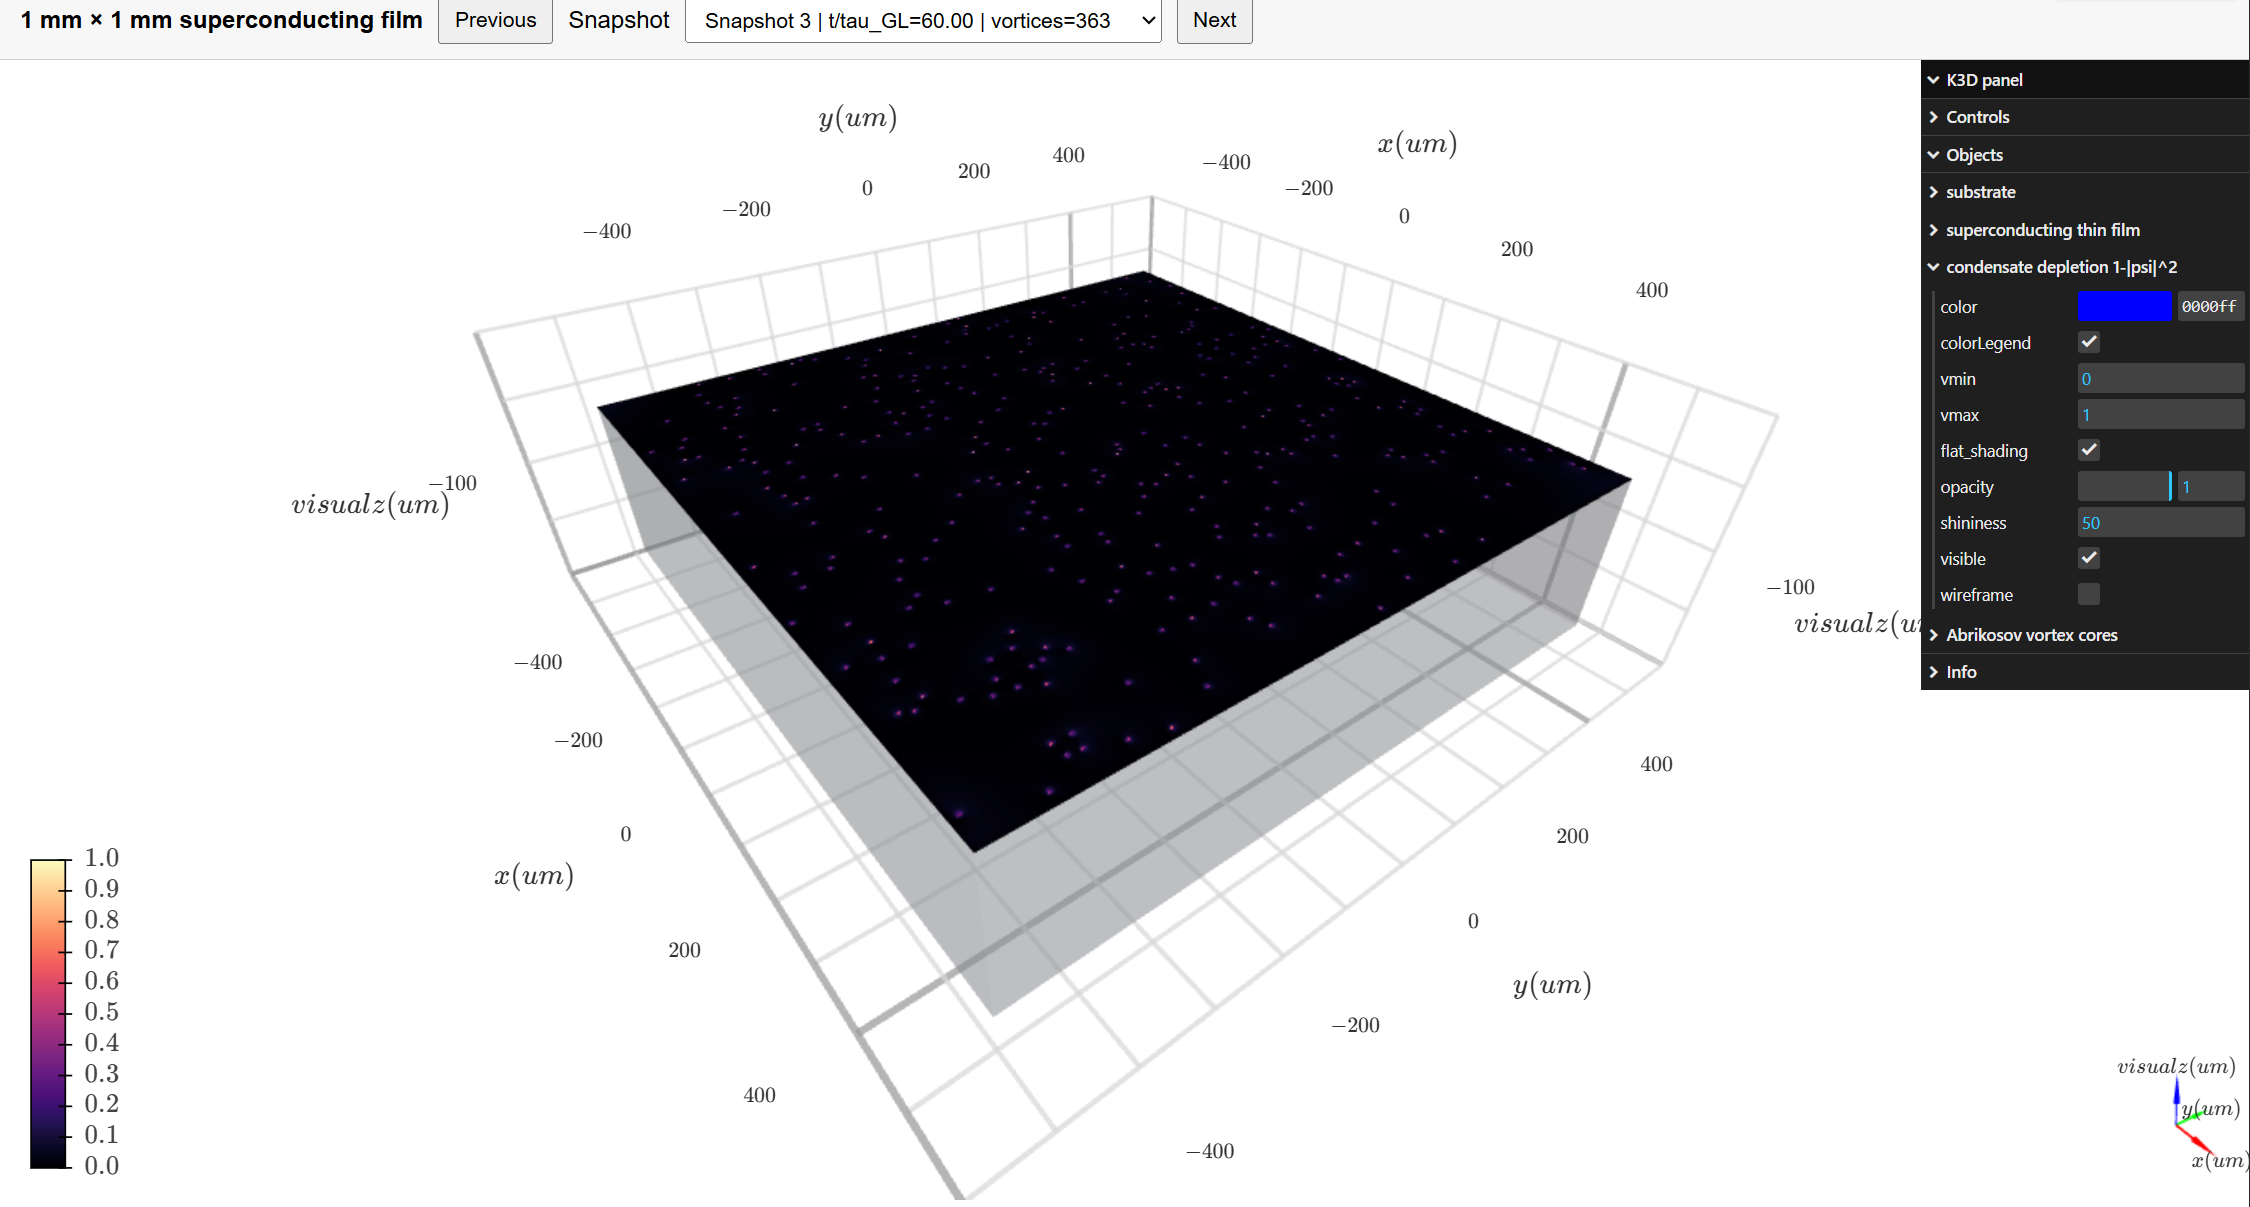

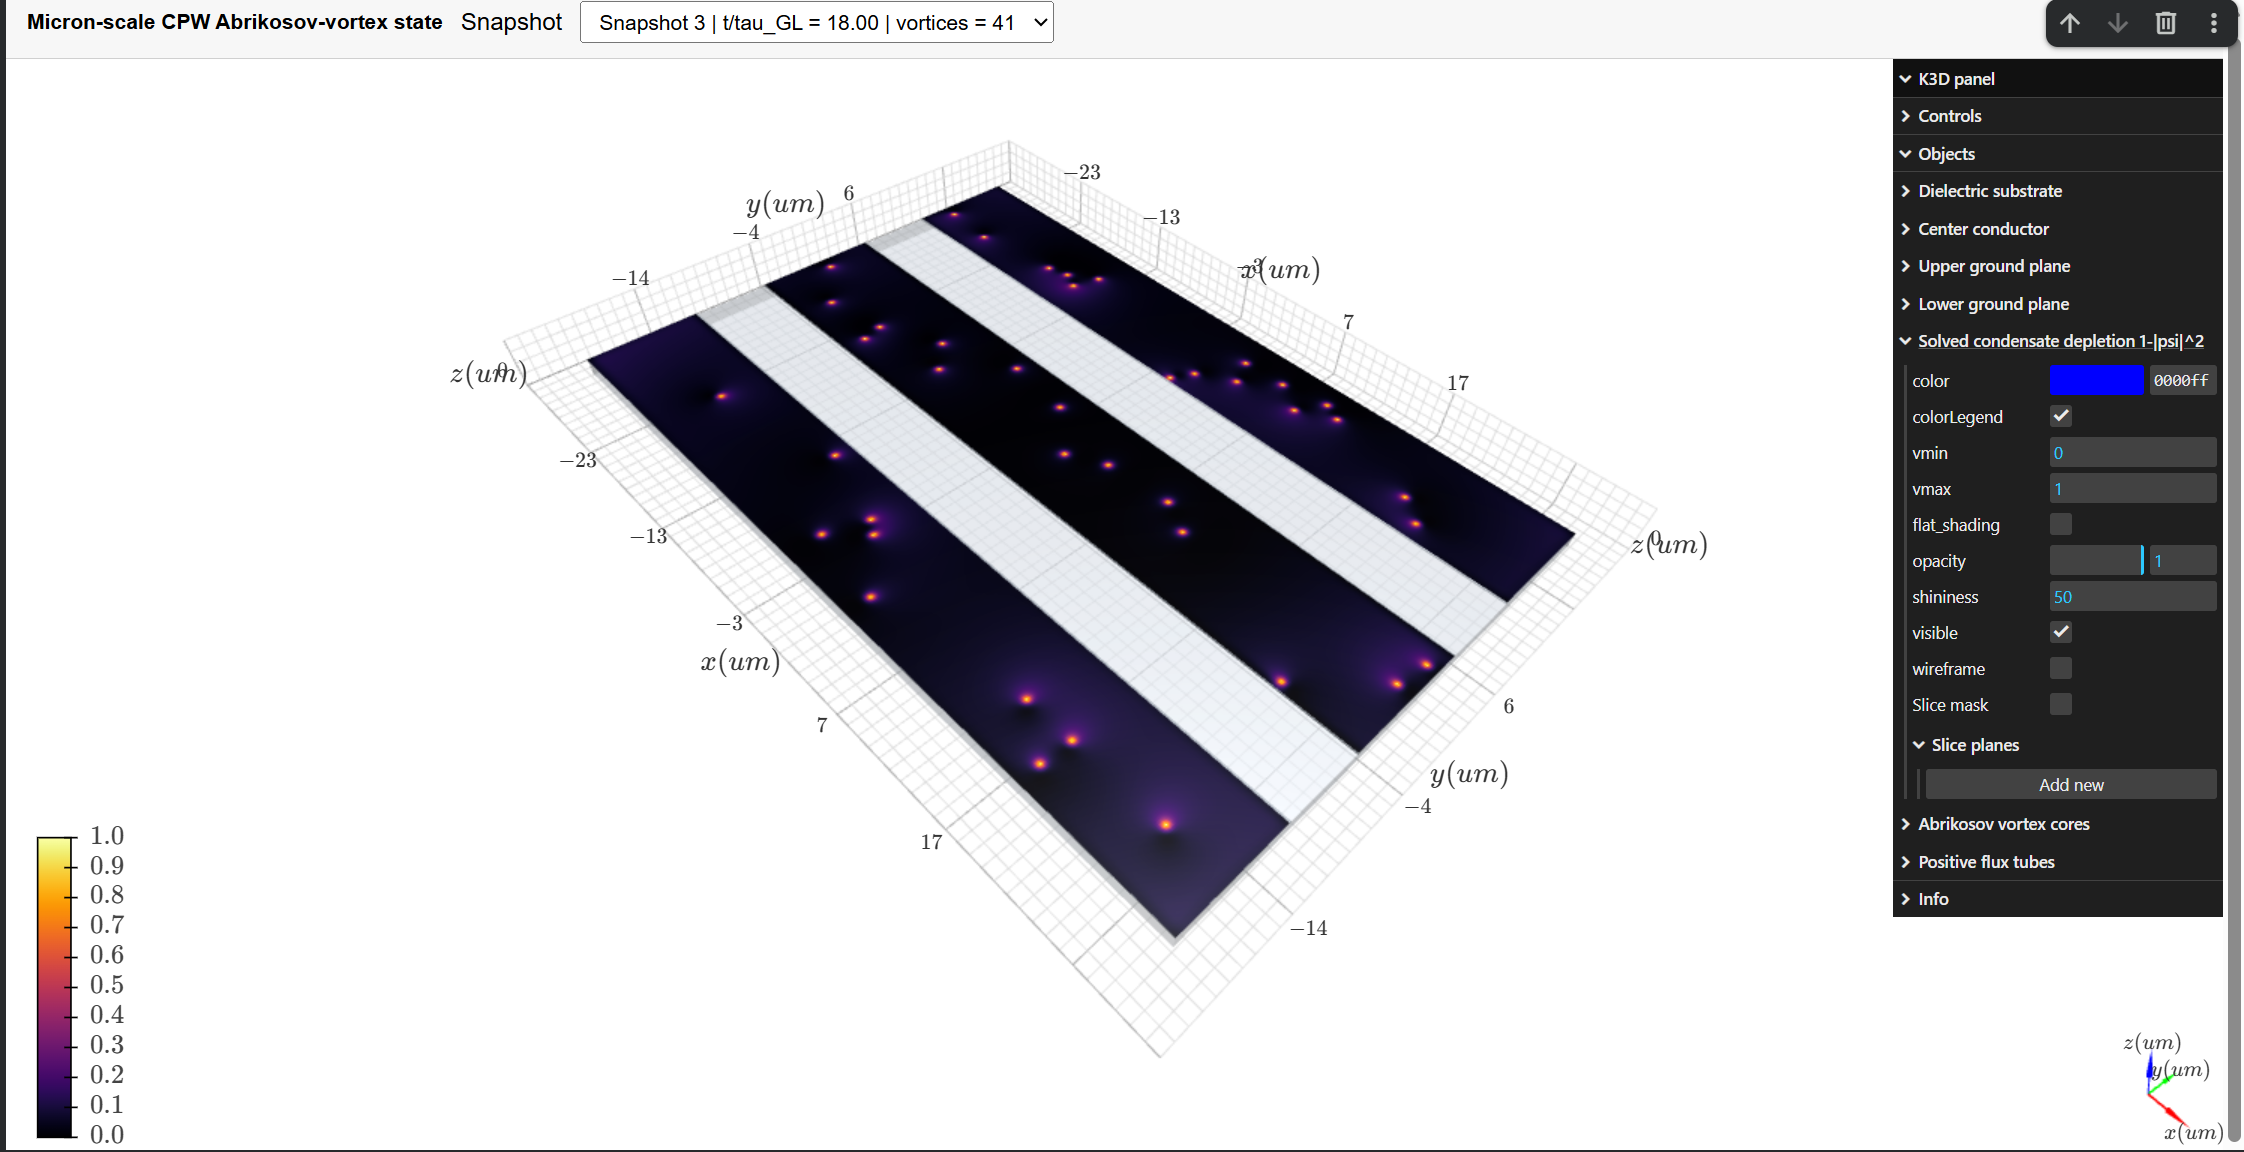